# Plotting

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from typing import List, Tuple, Optional


def _cell_to_numeric(maze: List[List]) -> np.ndarray:
    # Convert maze with mixed types to numeric array for display
    height = len(maze)
    width = len(maze[0])
    numeric_maze = np.zeros((height, width))

    cell_map = {
        0: 0,      # empty
        '.': 0,    # empty (alternative)
        '#': 1,    # wall
        1: 1,      # wall (alternate)
        'w': 1,    # wall (alternate)
        'r': 2,    # robot
        'R': 2,    # robot (alternate)
        'g': 3,    # goal
        'G': 3,    # goal (alternate)
        '@': 3,    # goal (alternate)
        'B': 4,    # block (treat as empty for visualization)
        'b': 4,    # block (alternate)
        'e': 5,    # elbow
    }

    for r in range(height):
        for c in range(width):
            cell = maze[r][c]
            numeric_maze[r][c] = cell_map.get(cell, 0)

    return numeric_maze


def plot_level(maze: List[List], title: str = "Sokoban Level", figsize: Tuple[int, int] = (8, 8)):
    # Plot a single sokoban level
    numeric_maze = _cell_to_numeric(maze)

    fig, ax = plt.subplots(figsize=figsize)

    # Create the base maze visualization
    cmap = plt.cm.colors.ListedColormap(['white', 'black', 'blue', 'red', 'brown', 'green'])
    im = ax.imshow(numeric_maze, cmap=cmap, origin='upper', vmin=0, vmax=5)

    # Add grid
    height, width = numeric_maze.shape
    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', size=0)

    # Set main ticks
    ax.set_xticks(np.arange(0, width, 1))
    ax.set_yticks(np.arange(0, height, 1))

    # Add legend
    legend_elements = [
        patches.Patch(facecolor='white', edgecolor='black', label='Empty'),
        patches.Patch(facecolor='black', edgecolor='black', label='Wall'),
        patches.Patch(facecolor='blue', edgecolor='black', label='Robot'),
        patches.Patch(facecolor='red', edgecolor='black', label='Goal'),
        patches.Patch(facecolor='brown', edgecolor='black', label='Box'),
        patches.Patch(facecolor='green', edgecolor='black', label='Elbow (empty)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.0, 1.0))

    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig, ax


def plot_multiple_levels(
    mazes: List[List[List]],
    titles: Optional[List[str]] = None,
    figsize: Tuple[int, int] = (15, 10)
):
    # Plot multiple sokoban levels in a grid
    n_mazes = len(mazes)
    cols = min(3, n_mazes)
    rows = (n_mazes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Handle single subplot case
    if n_mazes == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, maze in enumerate(mazes):
        ax = axes[idx]
        numeric_maze = _cell_to_numeric(maze)

        cmap = plt.cm.colors.ListedColormap(['white', 'black', 'blue', 'red', 'brown', 'green'])
        ax.imshow(numeric_maze, cmap=cmap, origin='upper', vmin=0, vmax=5)

        # Add grid
        height, width = numeric_maze.shape
        ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
        ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
        ax.tick_params(which='minor', size=0)

        ax.set_xticks(np.arange(0, width, 1))
        ax.set_yticks(np.arange(0, height, 1))

        if titles:
            ax.set_title(titles[idx], fontsize=11, fontweight='bold')
        else:
            ax.set_title(f'Level {idx + 1}', fontsize=11, fontweight='bold')

    # Hide unused subplots
    for idx in range(n_mazes, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    return fig, axes

# Level generator

##########
###ee#####
##r.b#####
####.#####
###e.e####
##...eee##
##e.....##
####.##@##
##########
##########



(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Sokoban Level'}>)

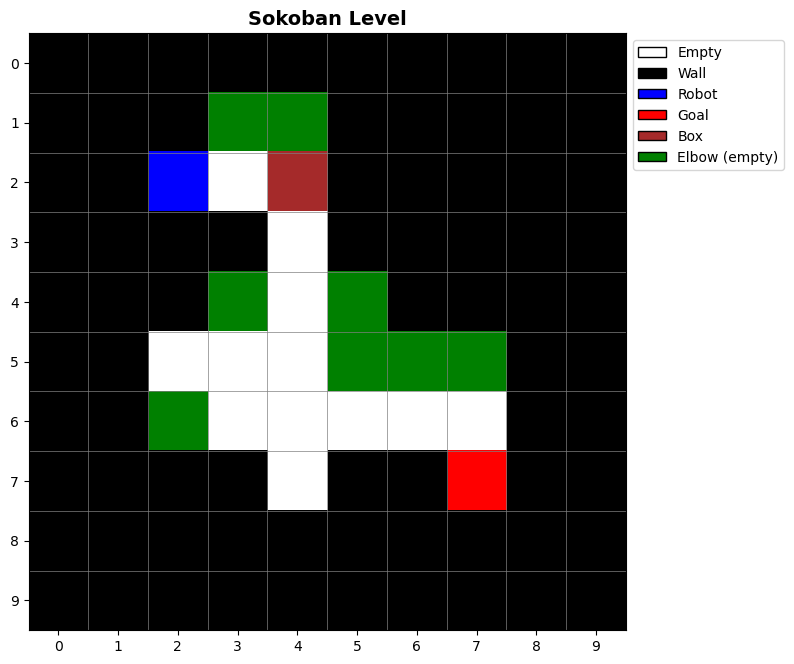

In [2]:
from typing import Tuple, List, Set
import random


"""
Base algorithm:
- We start from an empty grid with borders.
- We define robot position and goal position.
- We build a road connecting the two. The road might have an arbitrary number 
    of turns (in accordance with the size of the grid) 
- We enhance this road with "elbows", that the agent can use to push the box 
    towards the goal

This generates playable levels but the problem is that they are too simplistic:
there always is a single way leading to the goal, no complex cell arrangments, 
no crossing paths...

Enhanced algorithm:
- We iterate the above procedure a given number of times. This ensures 
    crossing paths and non-trivial global solutions.
- We apply an "erosion" step: we randomly remove some cells. This increase the 
    complexity of the maxe as the agent can now perform unnecessary actions
    and therefore produce non-optimal solutions.
- We apply a "deposition" step: we randomly add some cells. This should be done
    with criterion: adding cells could block the only path leading to the solution
    (even if we iterate the procedure, it could happen that for example the terminal
    part of the paths is shared across iterations and a new cell ends up blocking 
    all of them at the same time). We can add a block only if [???]
"""



"""
Cell encoding:
  1 / 'W' / 'w': Wall
  0:             Empty cell
  'r' / 'R':     Valid robot reset position
  'g' / 'G':     Valid goal position
"""
ENCODING = {
    'WALL': '#',
    'EMPTY': '.',
    'ROBOT': 'r',
    'GOAL': '@',
    'BLOCK': 'b',
    'ELBOW': 'e'
}

"""
Directions
"""
DIRECTIONS = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1)
}

"""
Fractions of the grid dimension used to define the spawn region.

These values limit random position selection to a sub-region of the
original grid. We will anchor it to the first and fourth quadrants
(this will be clear when the constants are actually used)

    row in [0, SPAWN_AREA_FRACTION_H * H)
    col in [0, SPAWN_AREA_FRACTION_W * W)

where H and W are the array height and width, SPAWN_AREA_FRACTION_H and 
SPAWN_AREA_FRACTION_W are the fractions for height and width respectively.

The resulting spawn region covers (SPAWN_AREA_FRACTION_H * SPAWN_AREA_FRACTION_W) 
of the total area (e.g. SAF_W=0.2, SAF_H=0.2 -> SPAWN_REGION=4%).
"""
ROBOT_SPAWN_AREA_FRACTION_W = 0.2
ROBOT_SPAWN_AREA_FRACTION_H = 0.2

# For the goal we will then
GOAL_SPAWN_AREA_FRACTION_W = 0.5
GOAL_SPAWN_AREA_FRACTION_H = 0.5

assert GOAL_SPAWN_AREA_FRACTION_W + ROBOT_SPAWN_AREA_FRACTION_W <= 1
assert GOAL_SPAWN_AREA_FRACTION_H + ROBOT_SPAWN_AREA_FRACTION_H <= 1

"""
Maximum and minimum grid sizes. We need to take into account that:
- we need to have at least a 1-cell border around the maze 
    (2 cells width/height reserved for this)
- we need to leave space for the path elbows
    (2 cells width/height reserved for this)
The cells introduced for the elbows are effectively playable, so the
effective playable grid size will simply be:

    MIN_GRID_WIDTH - 2
    MIN_GRID_HEIGHT - 2

"""
MIN_GRID_WIDTH, MAX_GRID_WIDTH = 6, 30
MIN_GRID_HEIGHT, MAX_GRID_HEIGHT = 6, 30


def pretty_print(maze: List[List]):

    for y in range(len(maze)):
        for x in range(len(maze[y])):
            print(maze[y][x], end='')
        print()
    print()


def string_to_maze(level: str) -> List[List]:
    arr = [[char for char in line] for line in level.splitlines()]
    if len(arr[0]) == 0:
        arr = arr[1:]
    return arr


def maze_to_string(maze: List[List]) -> str:
    result = []

    for y in range(len(maze)):
        row = []
        for x in range(len(maze[y])):
            row.append(str(maze[y][x]))
        result.append(''.join(row))

    return '\n'.join(result) + '\n'


def is_empty(maze: List[List], row: int, col: int):
    if row < 0 or row >= len(maze) or col < 0 or col >= len(maze[0]):
        return False
    return maze[row][col] == ENCODING['EMPTY']


def is_wall(maze: List[List], row: int, col: int):
    if row < 0 or row >= len(maze) or col < 0 or col >= len(maze[0]):
        return False
    return maze[row][col] == ENCODING['WALL']


def manhattan_distance(start: Tuple[int, int], end: Tuple[int, int]):
    """Simple Manhattan distance heuristic"""
    return abs(start[0] - end[0]) + abs(start[1] - end[1])


def get_random_empty_cell(maze: List[List], avoid: Set[Tuple[int, int]]=None):
    """
    Returns a random empty cell in the specified range
    
    Args:
        maze: the maze, duh
        avoid: set of cells we should avoid
    """

    if not avoid:
        avoid = set()

    height, width = len(maze), len(maze[0])

    # Gather all cells
    cells = {(r, c) for r in range(0, height) for c in range(0, width)}

    # Remove non-empty cells
    cells = {(r, c) for (r, c) in cells if is_empty(maze, r, c)}

    # Remove cells in avoid set
    cells = {(r, c) for (r, c) in cells if (r, c) not in avoid}

    if len(cells) == 0:
        raise ValueError("Something weng wrong, check the maze")

    # Return a random cell among the empty ones
    return random.sample(list(cells), 1)[0]


def add_elbows(path: List[Tuple]):
    """
    Add elbows to the path:

    +--+--+--+--+--+--+--+--+--+--+
    |  |ss|  |  |  |  |  |  |  |  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|  |  |  |  |  |ee|ee|  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|pp|pp|pp|pp|pp|pp|pp|  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|  |  |  |  |  |  |pp|  |
    +--+--+--+--+--+--+--+--+--+--+
    |  |pp|  |  |  |  |  |  |pp|..|
    +--+--+--+--+--+--+--+--+--+--+
    |ee|pp|  |  |  |  |  |  |  |  |     e.g.    p0 = (5, 1)
    +--+--+--+--+--+--+--+--+--+--+             p1 = (6, 1) 
    |ee|pp|pp|pp|pp|pp|pp|pp|pp|..|             p2 = (6, 2)
    +--+--+--+--+--+--+--+--+--+--+             d1 = (6-5, 1-1) = (1, 0) -> down
                                                d2 = (6-6, 2-1) = (0, 1) -> right

    - ss: start
    - pp: path
    - ee: elbow

    Note: elbow always involves only p0 and p1
    """

    assert len(path) >= 2, "What kind of path did you found you dumb ass"

    def has_turned(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # Direction vectors
        d1 = (x1 - x0, y1 - y0)
        d2 = (x2 - x1, y2 - y1)

        return d1 != d2

    def get_elbow_cells(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # d2 = (x2 - x1, y2 - y1)
        # e0 = p0 - d2
        # e1 = p1 - d2

        e0 = (x0 - x2 + x1, y0 - y2 + y1)
        e1 = (x1 - x2 + x1, y1 - y2 + y1) 
        
        return [e0, e1]

    elbow_cells = []
    for i in range(1, len(path) - 1):
        p0 = path[i-1]
        p1 = path[i]
        p2 = path[i+1]
        if has_turned(p0, p1, p2):
            elbow_cells.extend(get_elbow_cells(p0, p1, p2))

    return elbow_cells


def get_box_candidate_positions(path):
    """
    Get candidate box positions. To ensure solvability, we put the box either in:
    - a corridor
    - the elbow joint
    """

    assert len(path) >= 2, "What kind of path did you found you dumb ass"

    def has_turned(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # Direction vectors
        d1 = (x1 - x0, y1 - y0)
        d2 = (x2 - x1, y2 - y1)

        return d1 != d2

    def get_elbow_cells(p0: Tuple[int, int], p1: Tuple[int, int], p2: Tuple[int, int]):
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2

        # d2 = (x2 - x1, y2 - y1)
        # e0 = p0 - d2
        # e1 = p1 - d2

        e0 = (x0 - x2 + x1, y0 - y2 + y1)
        e1 = (x1 - x2 + x1, y1 - y2 + y1) 
        
        return [e0, e1]

    candidate_box_positions = []
    for i in range(1, len(path) - 1):
        p0 = path[i-1]
        p1 = path[i]
        p2 = path[i+1]
        if has_turned(p0, p1, p2):
            candidate_box_positions.append(p1)
    
    return candidate_box_positions


def lerw_waypoints(
        maze: List[List],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        spread: float = 0.3,
    ):
    """
    Farthest-Point Sampling: each new waypoint is drawn from a distribution
    weighted by min distance^2 to all already-chosen points.
    This maximizes spatial spread across the grid.
    """

    height, width = len(maze), len(maze[0])

    # TODO check this formula
    count = min(round(spread * 6), (width * height) // 8)

    if count == 0:
        return []

    chosen = [start, goal]
    waypoints = []

    for _ in range(count):
        candidates = [
            (x, y)
            for x in range(width) for y in range(height)
            if (x, y) not in chosen
        ]
        if not candidates:
            break

        # Weight by squared min-distance from any chosen point
        weights = [min(abs(x - cx) + abs(y - cy) for cx,cy in chosen)**2 for x,y in candidates]
        [wp] = random.choices(candidates, weights=weights, k=1)
        waypoints.append(wp)
        chosen.append(wp)

    # Greedy nearest-neighbor ordering from start
    ordered, remaining, cur = [], list(waypoints), start
    while remaining:
        nearest = min(remaining, key=lambda p: abs(p[0]-cur[0])+abs(p[1]-cur[1]))
        ordered.append(nearest)
        remaining.remove(nearest)
        cur = nearest

    return ordered


def lerw_path(
        maze: List[List], 
        start: Tuple[int, int], 
        goal: Tuple[int, int],
        entropy: float=0.3,
        spread: float=0.3
    ):
    """
    Loop-Erased Random Walk with waypoints for full-grid coverage.

    Args:
        entropy: 0.0 = greedy straight line, 1.0 = fully random local walk
        spread: 0.0 = direct (original behavior), 1.0 = many waypoints, full coverage
    """

    height, width = len(maze), len(maze[0])

    def neighbors(x, y):
        return [(x + dx, y + dy) for dx, dy in ((0,1), (0,-1), (1,0), (-1,0))
                if 0 <= x + dx < width and 0 <= y + dy < height]

    def biased_step(cell, target):
        opts = neighbors(*cell)
        if random.random() > entropy:
            return min(opts, key=lambda p: abs(p[0]-target[0])+abs(p[1]-target[1]))
        return random.choice(opts)

    def current_target_idx(targets, visited):
        return next((i for i, t in enumerate(targets) if t not in visited), len(targets))

    waypoints = lerw_waypoints(maze, start, goal, spread)
    targets = waypoints + [goal]

    path = [start]
    visited = {start: 0}

    while True:
        ti = current_target_idx(targets, visited)
        if ti >= len(targets):
            break

        current = path[-1]
        nxt = biased_step(current, targets[ti])

        if nxt in visited:
            loop_index = visited[nxt]
            for cell in path[loop_index + 1:]:
                del visited[cell]
            path = path[:loop_index + 1]
        else:
            visited[nxt] = len(path)
            path.append(nxt)

    return path


def apply_erosion(maze: List[List], strength: float = 0):
    """Randomly remove walls to increase complexity and open up the maze"""

    height, width = len(maze), len(maze[0])
    playable_cells = sum([
        1 if maze[r][c] == ENCODING['EMPTY'] or maze[r][c] == ENCODING['ELBOW'] else 0 
            for c in range(width) for r in range(height)
        ]
    )
    num_cells_to_erode = int(playable_cells * strength)

    while num_cells_to_erode > 0:

        # Pick a random cell
        r = random.randint(0, height - 1)
        c = random.randint(0, width - 1)

        if maze[r][c] == ENCODING['EMPTY']:
            continue
            
        if maze[r][c] == ENCODING['ROBOT']:
            continue

        if maze[r][c] == ENCODING['GOAL']:
            continue
 
        # Check all possible neighbors
        neighbors = {(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)}

        # Keep only the existing ones
        neighbors = set([neighbor for neighbor in neighbors if neighbor[0] < height and neighbor[1] < width])

        num_empty_neighbors = sum([1 if maze[neighbor[0]][neighbor[1]] == ENCODING['EMPTY'] else 0 for neighbor in neighbors])

        # Accept the cell only if a neighbor is empty
        # We can even be more restrictive and keep only cells with at least 2 empty neighbors
        if num_empty_neighbors < 1:
            continue

        # Finally, erosion could happen
        maze[r][c] = ENCODING['EMPTY']

        # If erosion successful, decrement counter
        num_cells_to_erode -= 1


def apply_deposition(maze: List[List], strength: float = 0):
    raise ValueError("Not implemented")


def add_borders(maze: List[List]):
    """Add wall borders around the maze"""
    
    height, width = len(maze), len(maze[0])
    new_height, new_width = height + 2, width + 2
 
    new_maze = [[ENCODING['EMPTY'] for _ in range(new_width)] for _ in range(new_height)]

    # Top and bottom borders
    for c in range(new_width):
        new_maze[0][c] = ENCODING['WALL']
        new_maze[new_height - 1][c] = ENCODING['WALL']
 
    # Left and right borders
    for r in range(new_height):
        new_maze[r][0] = ENCODING['WALL']
        new_maze[r][new_width - 1] = ENCODING['WALL']

    # Copy old maze into new one
    for c in range(width):
        for r in range(height):
            new_maze[c + 1][r + 1] = maze[c][r]

    return new_maze


def widen_path(
        path: List[Tuple[int, int]],
        maze: List[List],
        corridor_width: int = 2
    ) -> Set[Tuple[int, int]]:
    """
    Expand a 1-cell-wide spine path into a multi-cell-wide corridor.

    The spine itself is kept as-is (use it for add_elbows / get_box_candidate_positions).
    This function returns the FULL set of cells including the spine and
    the lateral expansion, suitable for carving into the maze.

    Expansion direction: clockwise perpendicular to local travel direction.
    At turns, both the pre-turn and post-turn directions are used so
    the corner pocket is always filled.

    Args:
        path: ordered list of (row, col) cells from lerw_path
        maze: the maze, used only for boundary checks
        corridor_width: total corridor width in cells (1 = no expansion)

    Returns:
        set of (row, col) cells belonging to the widened corridor
    """

    assert corridor_width >= 1, "corridor_width must be >= 1"
    assert len(path) >= 2, "path must have at least 2 cells"

    height, width = len(maze), len(maze[0])
    wide: Set[Tuple[int, int]] = set(path)

    def in_bounds(r: int, c: int) -> bool:
        return 0 <= r < height and 0 <= c < width

    def cw_perp(dr: int, dc: int) -> Tuple[int, int]:
        # Clockwise 90-degree rotation: (dr, dc) -> (dc, -dr)
        return dc, -dr

    def directions_at(i: int) -> List[Tuple[int, int]]:
        # Collect all local direction vectors at index i
        dirs = []
        if i < len(path) - 1:
            r0, c0 = path[i]
            r1, c1 = path[i + 1]
            dirs.append((r1 - r0, c1 - c0))
        if i > 0:
            r0, c0 = path[i - 1]
            r1, c1 = path[i]
            dirs.append((r1 - r0, c1 - c0))
        return dirs

    for i, (row, col) in enumerate(path):
        for dr, dc in directions_at(i):
            pr, pc = cw_perp(dr, dc)
            for w in range(1, corridor_width):
                nr, nc = row + pr * w, col + pc * w
                if in_bounds(nr, nc):
                    wide.add((nr, nc))

    return wide


def generate_maze(
        height: int, 
        width: int, 
        num_road_iterations: int = 1,
        corridor_width: int = 1,
        erosion_strength: float = 0.0,
        deposition_strength: float = 0.0,
        seed: int = None,
        **kwargs
    ) -> List[List]:
    """
    Generate a random maze using recursive backtracking. 
    The maze will feature a single block and a single goal position.
    """

    random.seed(seed)

    assert MIN_GRID_WIDTH <= width <= MAX_GRID_WIDTH, f"Maze width out of bounds({width}), should be {MIN_GRID_WIDTH} <= x <= {MAX_GRID_WIDTH}."
    assert MIN_GRID_HEIGHT <= height <= MAX_GRID_HEIGHT, f"Maze height out of bounds ({height}), should be {MIN_GRID_HEIGHT} <= y <= {MAX_GRID_HEIGHT}."

    full_width, full_height = width, height
    workable_width, workable_height = width - 4, height - 4

    # Generate a grid full of wall cells 
    full_maze = [[ENCODING['WALL'] for _ in range(full_width)] for _ in range(full_height)]
    workable_maze = [[ENCODING['WALL'] for _ in range(workable_width)] for _ in range(workable_height)]

    # Define robot position
    robot_x = int(random.random() * ROBOT_SPAWN_AREA_FRACTION_W * workable_width)
    robot_y = int(random.random() * ROBOT_SPAWN_AREA_FRACTION_H * workable_height)
    robot_position = (robot_x, robot_y)
    workable_maze[robot_x][robot_y] = ENCODING['ROBOT']

    # Define goal position
    goal_x = workable_width - int(random.random() * GOAL_SPAWN_AREA_FRACTION_W * workable_width) - 1
    goal_y = workable_height - int(random.random() * GOAL_SPAWN_AREA_FRACTION_H * workable_height) - 1
    goal_position = (goal_x, goal_y)
    workable_maze[goal_x][goal_y] = ENCODING['GOAL']

    # Build roads connecting start to goal
    paths = []
    path_cells = set()
    for _ in range(num_road_iterations):
        path = lerw_path(workable_maze, robot_position, goal_position, **kwargs)
        wide_cells = widen_path(path, workable_maze, corridor_width=corridor_width)
        paths.append(path)  # spine still used for elbows / box positions
        path_cells = path_cells.union(wide_cells)  # wider carving

    # Get elbow cells
    elbows = []
    for path in paths:
        elbows.append(add_elbows(path))

    # Get positions where we can put the box
    boxes = []
    for path in paths:
        boxes.append(get_box_candidate_positions(path))

    # Dump all the stuff on the new maze
    full_maze[robot_x + 2][robot_y + 2] = ENCODING['ROBOT']
    full_maze[goal_x + 2][goal_y + 2] = ENCODING['GOAL']

    path_cells = path_cells.union(set([cell for path in paths for cell in path]))
    elbow_cells = set([cell for elbow in elbows for cell in elbow])
    box_cells = set([cell for box in boxes for cell in box]) - {robot_position} - {goal_position}
    cells = path_cells.union(elbow_cells)

    for cell in cells:
        if cell != goal_position and cell != robot_position:
            row, col = cell
            if cell in path_cells:
                full_maze[row + 2][col + 2] = ENCODING['EMPTY']
            else:
                full_maze[row + 2][col + 2] = ENCODING['ELBOW']

    # Apply erosion. This does not invalidate any solution to the problem,
    # it just adds maze complexity
    if erosion_strength > 0.0:
        apply_erosion(full_maze, erosion_strength)

    # Apply deposition
    if deposition_strength > 0.0:
        apply_deposition(full_maze, deposition_strength)

    # Any free cell at this point is a candidate for the block,
    # but we need to carefully analyze where to put it as this can
    # invalidate the solution.
    # Solution: place the block on p1 or in corridors
    #       (we know for sure we can push the box from there)
    # block_x, block_y = get_random_empty_cell(maze, avoid=elbow_cells)
    block_x, block_y = random.sample(sorted(box_cells), 1)[0]
    block_position = (block_x, block_y)
    if block_position == (-1, -1):
        raise ValueError(f"Cannot place block, check the maze.")
    full_maze[block_x + 2][block_y + 2] = ENCODING['BLOCK']
        
    # Enforce borders (erosion could breach the maze)
    for r in range(full_height):
        full_maze[r][0] = ENCODING['WALL']
        full_maze[r][full_width - 1] = ENCODING['WALL']

    for c in range(full_width):
        full_maze[0][c] = ENCODING['WALL']
        full_maze[full_height - 1][c] = ENCODING['WALL']

    return full_maze


maze = generate_maze(10, 10, erosion_strength=0.1)
pretty_print(maze)
plot_level(maze)

# Check solvability

In [3]:
# !pip install --pre unified-planning
!git clone https://github.com/speckdavid/unified-planning
!pip install unified-planning/

!pip install up-symk

fatal: destination path 'unified-planning' already exists and is not an empty directory.
Processing ./unified-planning
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unified_planning: filename=unified_planning-0.6.0.382.dev1-py3-none-any.whl size=646868 sha256=40ceb6d99412aa62314035047a0ca146d8435b6ebf13db192ab3f4fb60e6e6e6
  Stored in directory: /home/daniel/.cache/pip/wheels/9b/7f/73/6070cb4fad88a71a432ace7b52bf4bd79d96f2fb0045e5a181
Successfully built unified_planning
  Attempting uninstall: unified_planning
    Found existing installation: unified_planning 0.6.0.382.dev1
    Uninstalling unified_planning-0.6.0.382.dev1:
      Successfully uninstalled unified_planning-0.6.0.382.dev1


In [4]:
import unified_planning as up
import up_symk
from unified_planning.shortcuts import *
from unified_planning.io import PDDLWriter, PDDLReader

In [7]:
"""
Use same encoding as above

ENCODING = {
    'WALL': '#',
    'EMPTY': '.',
    'ROBOT': 'r',
    'GOAL': '@',
    'BLOCK': 'b',
    'ELBOW': 'e'
}
"""

def create_sokoban_problem(level, with_axioms=False):
    problem = up.model.Problem("sokoban")
    
    loc = UserType("location")

    has_player, has_box, adjacent, adjacent_2, can_reach = (
        up.model.Fluent("has_player", BoolType(), l=loc),
        up.model.Fluent("has_box", BoolType(), l=loc),
        up.model.Fluent("adjacent", BoolType(), l1=loc, l2=loc),
        up.model.Fluent("adjacent_2", BoolType(), l1=loc, l2=loc),
        up.model.Fluent("can_reach", DerivedBoolType(), l=loc) if with_axioms else None,
    )

    for fluent in [has_player, has_box, adjacent, adjacent_2, can_reach]:
        if fluent:
            problem.add_fluent(fluent, default_initial_value=False)

    if with_axioms:
        # Axiom 1
        a1 = up.model.Axiom("reach-axiom-1", l=loc)
        a1.set_head(can_reach(a1.parameters[0]))
        a1.add_body_condition(has_player(a1.parameters[0]))
        problem.add_axiom(a1)

        # Axiom 2
        a2 = up.model.Axiom("reach-axiom-2", to=loc)
        to, fr = a2.parameters[0], Variable("from", loc)
        a2.set_head(can_reach(to))
        a2.add_body_condition(Not(has_box(to)))
        a2.add_body_condition(
            Exists(
                And(
                    can_reach(fr),
                    adjacent(fr, to)
                ),
                fr
            )
        )
        problem.add_axiom(a2)

    cost_dict = {}
    
    if not with_axioms:
        # Move action
        move = up.model.InstantaneousAction("move", fr=loc, to=loc)
        fr, to = move.parameters
        move.add_precondition(adjacent(fr, to))
        move.add_precondition(has_player(fr))
        move.add_precondition(Not(has_box(to)))
        move.add_effect(has_player(fr), False)
        move.add_effect(has_player(to), True)
        cost_dict[move] = 0
        problem.add_action(move)

        # Push box
        push_box = up.model.InstantaneousAction("push-box", x=loc, y=loc, z=loc)
        x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(x), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

    if with_axioms:
        # Push box
        push_box = up.model.InstantaneousAction("push-box", l=loc, x=loc, y=loc, z=loc)
        l, x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(l))
        push_box.add_precondition(can_reach(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(l), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

    problem.add_quality_metric(up.model.metrics.MinimizeActionCosts(cost_dict))

    # Encode level
    level_array = [[char for char in line] for line in level.splitlines()]
    num_col, num_row = len(level_array[0]), len(level_array)
    
    loc_objs = {}

    for x in range(num_col):
        for y in range(num_row):
            entry = level_array[y][x]
            if entry != ENCODING['WALL']:
                loc_id = f"loc-{x}-{y}"
                cur_obj = up.model.Object(loc_id, loc)
                loc_objs[loc_id] = cur_obj
                problem.add_object(cur_obj)

                if entry == ENCODING['ROBOT']:
                    problem.set_initial_value(has_player(cur_obj), True)
                elif entry == ENCODING['BLOCK']:
                    problem.set_initial_value(has_box(cur_obj), True)
                elif entry == ENCODING['GOAL']:
                    problem.add_goal(has_box(cur_obj))

    # Set adjacency relationships
    for obj1 in loc_objs:
        for obj2 in loc_objs:
            x1, y1 = map(int, str(obj1).split("-")[1:])
            x2, y2 = map(int, str(obj2).split("-")[1:])
            distance = abs(x1 - x2) + abs(y1 - y2)

            if distance == 1:
                problem.set_initial_value(adjacent(loc_objs[obj1], loc_objs[obj2]), True)
            elif distance == 2 and (x1 == x2 or y1 == y2):
                problem.set_initial_value(adjacent_2(loc_objs[obj1], loc_objs[obj2]), True)

    return problem

####################
####################
###ee###############
###rb###############
####.###############
###e.##.e###########
###e.....###########
#######e.e##########
#######e..##########
########...#ee######
########e.....######
#############@######
####################
####################
####################
####################
####################
####################
####################
####################

NOTE: To disable printing of planning engine credits, add this line to your code: `up.shortcuts.get_environment().credits_stream = None`
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 10 of `/tmp/ipykernel_1632049/3504183762.py`, you are using the following planning engine:
  * Engine name: SymK
  * Developers:  David Speck (cf. https://github.com/speckdavid/symk/blob/master/README.md )
  * Description: SymK is a state-of-the-art domain-independent optimal and top-k planner.

SymK found this plan:
SequentialPlan:
    push-box(loc-3-3, loc-4-2, loc-4-3, lo

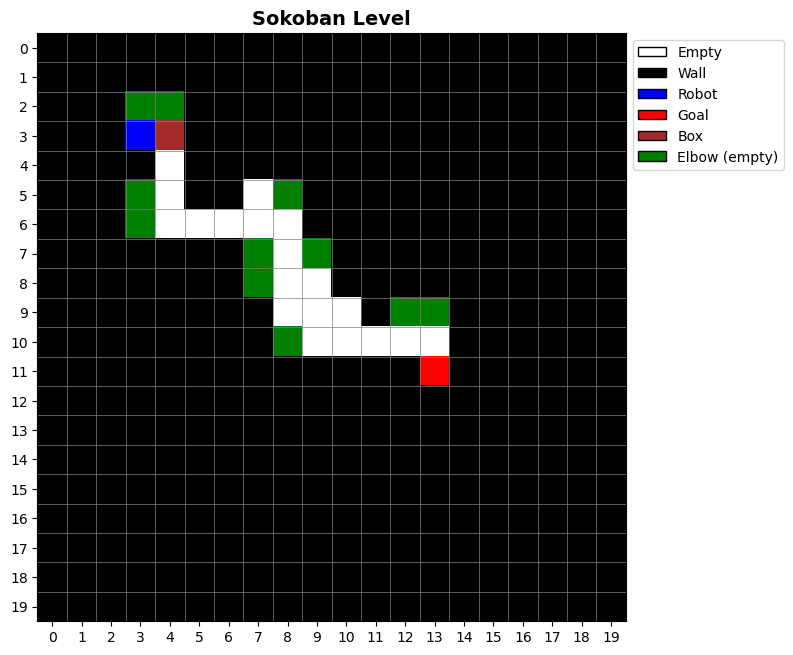

In [8]:
# Generate a level and the corresponding problem
sokoban_level = generate_maze(20, 20, erosion_strength=0.1)
stringified_level = maze_to_string(sokoban_level)
sokoban_problem = create_sokoban_problem(stringified_level, with_axioms=True)

pretty_print(sokoban_level)
plot_level(sokoban_level)

# Solve the problem
with OneshotPlanner(problem_kind=sokoban_problem.kind) as planner:
    result = planner.solve(sokoban_problem) # , output_stream=sys.stdout
    if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
        print(f"{planner.name} found this plan:")
        print(result.plan)
    else:
        print("No plan found.")

# Problem extensions

Original fluents:
- has_player(l) = "the player is at location l"
- has_box(l) = "a box is at location l"
- adjacent(l1, l2) = "locations l1 and l2 are 1 step apart (same row/col)"
- adjacent_2(l1, l2) = "locations l1 and l2 are 2 steps apart (same row/col)" (used to verify push direction alignment)
- can_reach(l) (axiom variant only) = derived fluent, computed automatically from axiom rules

Locations are every non-wall in the grid.
Walls are simply absent.

Actions:
- move(fr, to): player moves from `fr` to `to`. Requires adjacency of `fr` to `to`, player presence in `fr`, no box at destination `to`.
- push-box(pl, fr, to): player at `pl` pushes a box from `fr` to `to`. Requires `pl` collinear to `fr` and `to`, player at `pl`, box at `fr`, no box at `to`.   

In case of axioms:
- push-box(pl, x, y, z): player at `pl` at cell `x` pushes box at cell `y` to cell `z`

## Diagonal movement

In [9]:
def create_diagonal_sokoban_problem(level, with_axioms=False, with_diagonal_push=True):
    problem = up.model.Problem("sokoban")
    
    loc = UserType("location")

    has_player = up.model.Fluent("has_player", BoolType(), l=loc)
    has_box = up.model.Fluent("has_box", BoolType(), l=loc)
    adjacent = up.model.Fluent("adjacent", BoolType(), l1=loc, l2=loc)
    adjacent_2 = up.model.Fluent("adjacent_2", BoolType(), l1=loc, l2=loc)

    problem.add_fluent(has_player, default_initial_value=False)
    problem.add_fluent(has_box, default_initial_value=False)
    problem.add_fluent(adjacent, default_initial_value=False)
    problem.add_fluent(adjacent_2, default_initial_value=False)
    
    if with_axioms:
        can_reach = up.model.Fluent("can_reach", DerivedBoolType(), l=loc)
        problem.add_fluent(can_reach, default_initial_value=False)

    # Pure diagonal adjacency
    adjacent_diag = up.model.Fluent("adjacent_diag", BoolType(), l1=loc, l2=loc)
    problem.add_fluent(adjacent_diag, default_initial_value=False)

    if with_diagonal_push:
        adjacent_2_diag = up.model.Fluent("adjacent_2_diag", BoolType(), l1=loc, l2=loc)
        problem.add_fluent(adjacent_2_diag, default_initial_value=False)

    if with_axioms:
        # Axiom 1
        a1 = up.model.Axiom("reach-axiom-1", l=loc)
        a1.set_head(can_reach(a1.parameters[0]))
        a1.add_body_condition(has_player(a1.parameters[0]))
        problem.add_axiom(a1)

        # Axiom 2
        a2 = up.model.Axiom("reach-axiom-2", to=loc)
        to, fr = a2.parameters[0], Variable("from", loc)
        a2.set_head(can_reach(to))
        a2.add_body_condition(Not(has_box(to)))
        a2.add_body_condition(
            Exists(
                And(
                    can_reach(fr),
                    adjacent(fr, to)
                ),
                fr
            )
        )
        problem.add_axiom(a2)

    cost_dict = {}
    
    if not with_axioms:
        # Move action
        move = up.model.InstantaneousAction("move", fr=loc, to=loc)
        fr, to = move.parameters
        move.add_precondition(adjacent(fr, to))
        move.add_precondition(has_player(fr))
        move.add_precondition(Not(has_box(to)))
        move.add_effect(has_player(fr), False)
        move.add_effect(has_player(to), True)
        cost_dict[move] = 0
        problem.add_action(move)

        # Move diagonally
        move_diag = up.model.InstantaneousAction("move-diag", fr=loc, to=loc)
        fr, to = move_diag.parameters
        move_diag.add_precondition(adjacent_diag(fr, to))
        move_diag.add_precondition(has_player(fr))
        move_diag.add_precondition(Not(has_box(to)))
        move_diag.add_effect(has_player(fr), False)
        move_diag.add_effect(has_player(to), True)
        cost_dict[move_diag] = 0
        problem.add_action(move_diag)

        # Push box
        push_box = up.model.InstantaneousAction("push-box", x=loc, y=loc, z=loc)
        x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(x), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

        if with_diagonal_push:
            push_box_diag = up.model.InstantaneousAction("push-box-diag", x=loc, y=loc, z=loc)
            x, y, z = push_box_diag.parameters

            push_box_diag.add_precondition(adjacent_diag(x, y))      # player to box: diagonal step
            push_box_diag.add_precondition(adjacent_diag(y, z))      # box to dest:  diagonal step
            push_box_diag.add_precondition(adjacent_2_diag(x, z))    # collinearity: same diagonal direction
            push_box_diag.add_precondition(has_player(x))
            push_box_diag.add_precondition(has_box(y))
            push_box_diag.add_precondition(Not(has_box(z)))

            push_box_diag.add_effect(has_player(x), False)
            push_box_diag.add_effect(has_player(y), True)
            push_box_diag.add_effect(has_box(y), False)
            push_box_diag.add_effect(has_box(z), True)

            cost_dict[push_box_diag] = 1
            problem.add_action(push_box_diag)


    if with_axioms:
        # Push box
        push_box = up.model.InstantaneousAction("push-box", l=loc, x=loc, y=loc, z=loc)
        l, x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(l))
        push_box.add_precondition(can_reach(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(l), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

    problem.add_quality_metric(up.model.metrics.MinimizeActionCosts(cost_dict))

    # Encode level
    level_array = [[char for char in line] for line in level.splitlines()]
    num_col, num_row = len(level_array[0]), len(level_array)
    
    loc_objs = {}

    for x in range(num_col):
        for y in range(num_row):
            entry = level_array[y][x]
            if entry != ENCODING['WALL']:
                loc_id = f"loc-{x}-{y}"
                cur_obj = up.model.Object(loc_id, loc)
                loc_objs[loc_id] = cur_obj
                problem.add_object(cur_obj)

                if entry == ENCODING['ROBOT']:
                    problem.set_initial_value(has_player(cur_obj), True)
                elif entry == ENCODING['BLOCK']:
                    problem.set_initial_value(has_box(cur_obj), True)
                elif entry == ENCODING['GOAL']:
                    problem.add_goal(has_box(cur_obj))

    # Set adjacency relationships
    for obj1 in loc_objs:
        for obj2 in loc_objs:
            x1, y1 = map(int, str(obj1).split("-")[1:])
            x2, y2 = map(int, str(obj2).split("-")[1:])
            distance = abs(x1 - x2) + abs(y1 - y2)

            if distance == 1:
                problem.set_initial_value(adjacent(loc_objs[obj1], loc_objs[obj2]), True)
            elif distance == 2 and (x1 == x2 or y1 == y2):
                problem.set_initial_value(adjacent_2(loc_objs[obj1], loc_objs[obj2]), True)
            elif abs(x1 - x2) == 1 and abs(y1 - y2) == 1:
                problem.set_initial_value(adjacent_diag(loc_objs[obj1], loc_objs[obj2]), True)
            elif abs(x1 - x2) == 2 and abs(y1 - y2) == 2:
                # Same diagonal, 2 steps apart — collinearity check for diagonal pushes
                problem.set_initial_value(adjacent_2_diag(loc_objs[obj1], loc_objs[obj2]), True)

    return problem

## Diagonal movement only if no corner

In [10]:
def create_free_diagonal_sokoban_problem(level, with_axioms=False, with_diagonal_push=True):
    problem = up.model.Problem("sokoban")
    
    loc = UserType("location")

    has_player = up.model.Fluent("has_player", BoolType(), l=loc)
    has_box = up.model.Fluent("has_box", BoolType(), l=loc)
    adjacent = up.model.Fluent("adjacent", BoolType(), l1=loc, l2=loc)
    adjacent_2 = up.model.Fluent("adjacent_2", BoolType(), l1=loc, l2=loc)

    problem.add_fluent(has_player, default_initial_value=False)
    problem.add_fluent(has_box, default_initial_value=False)
    problem.add_fluent(adjacent, default_initial_value=False)
    problem.add_fluent(adjacent_2, default_initial_value=False)
    
    if with_axioms:
        can_reach = up.model.Fluent("can_reach", DerivedBoolType(), l=loc)
        problem.add_fluent(can_reach, default_initial_value=False)

    # Pure diagonal adjacency
    adjacent_diag = up.model.Fluent("adjacent_diag", BoolType(), l1=loc, l2=loc)
    problem.add_fluent(adjacent_diag, default_initial_value=False)

    if with_diagonal_push:
        adjacent_2_diag = up.model.Fluent("adjacent_2_diag", BoolType(), l1=loc, l2=loc)
        problem.add_fluent(adjacent_2_diag, default_initial_value=False)

    if with_axioms:
        # Axiom 1
        a1 = up.model.Axiom("reach-axiom-1", l=loc)
        a1.set_head(can_reach(a1.parameters[0]))
        a1.add_body_condition(has_player(a1.parameters[0]))
        problem.add_axiom(a1)

        # Axiom 2
        a2 = up.model.Axiom("reach-axiom-2", to=loc)
        to, fr = a2.parameters[0], Variable("from", loc)
        a2.set_head(can_reach(to))
        a2.add_body_condition(Not(has_box(to)))
        a2.add_body_condition(
            Exists(
                And(
                    can_reach(fr),
                    adjacent(fr, to)
                ),
                fr
            )
        )
        problem.add_axiom(a2)

    cost_dict = {}
    
    if not with_axioms:
        # Move action
        move = up.model.InstantaneousAction("move", fr=loc, to=loc)
        fr, to = move.parameters
        move.add_precondition(adjacent(fr, to))
        move.add_precondition(has_player(fr))
        move.add_precondition(Not(has_box(to)))
        move.add_effect(has_player(fr), False)
        move.add_effect(has_player(to), True)
        cost_dict[move] = 0
        problem.add_action(move)

        # Move diagonally
        move_diag = up.model.InstantaneousAction("move-diag", fr=loc, to=loc)
        fr, to = move_diag.parameters
        move_diag.add_precondition(adjacent_diag(fr, to))
        move_diag.add_precondition(has_player(fr))
        move_diag.add_precondition(Not(has_box(to)))
        move_diag.add_effect(has_player(fr), False)
        move_diag.add_effect(has_player(to), True)
        cost_dict[move_diag] = 0
        problem.add_action(move_diag)

        # Push box
        push_box = up.model.InstantaneousAction("push-box", x=loc, y=loc, z=loc)
        x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(x), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

        if with_diagonal_push:
            push_box_diag = up.model.InstantaneousAction("push-box-diag", x=loc, y=loc, z=loc)
            x, y, z = push_box_diag.parameters

            push_box_diag.add_precondition(adjacent_diag(x, y))      # player to box: diagonal step
            push_box_diag.add_precondition(adjacent_diag(y, z))      # box to dest:  diagonal step
            push_box_diag.add_precondition(adjacent_2_diag(x, z))    # collinearity: same diagonal direction
            push_box_diag.add_precondition(has_player(x))
            push_box_diag.add_precondition(has_box(y))
            push_box_diag.add_precondition(Not(has_box(z)))

            push_box_diag.add_effect(has_player(x), False)
            push_box_diag.add_effect(has_player(y), True)
            push_box_diag.add_effect(has_box(y), False)
            push_box_diag.add_effect(has_box(z), True)

            cost_dict[push_box_diag] = 1
            problem.add_action(push_box_diag)

    if with_axioms:
        # Push box
        push_box = up.model.InstantaneousAction("push-box", l=loc, x=loc, y=loc, z=loc)
        l, x, y, z = push_box.parameters
        push_box.add_precondition(adjacent(x, y))
        push_box.add_precondition(adjacent(y, z))
        push_box.add_precondition(adjacent_2(x, z))
        push_box.add_precondition(has_player(l))
        push_box.add_precondition(can_reach(x))
        push_box.add_precondition(has_box(y))
        push_box.add_precondition(Not(has_box(z)))
        push_box.add_effect(has_player(l), False)
        push_box.add_effect(has_player(y), True)
        push_box.add_effect(has_box(y), False)
        push_box.add_effect(has_box(z), True)
        cost_dict[push_box] = 1
        problem.add_action(push_box)

    problem.add_quality_metric(up.model.metrics.MinimizeActionCosts(cost_dict))

    # Encode level
    level_array = [[char for char in line] for line in level.splitlines()]
    num_col, num_row = len(level_array[0]), len(level_array)
    
    loc_objs = {}

    for x in range(num_col):
        for y in range(num_row):
            entry = level_array[y][x]
            if entry != ENCODING['WALL']:
                loc_id = f"loc-{x}-{y}"
                cur_obj = up.model.Object(loc_id, loc)
                loc_objs[loc_id] = cur_obj
                problem.add_object(cur_obj)

                if entry == ENCODING['ROBOT']:
                    problem.set_initial_value(has_player(cur_obj), True)
                elif entry == ENCODING['BLOCK']:
                    problem.set_initial_value(has_box(cur_obj), True)
                elif entry == ENCODING['GOAL']:
                    problem.add_goal(has_box(cur_obj))

    # Set adjacency relationships
    for obj1 in loc_objs:
        for obj2 in loc_objs:
            x1, y1 = map(int, str(obj1).split("-")[1:])
            x2, y2 = map(int, str(obj2).split("-")[1:])
            distance = abs(x1 - x2) + abs(y1 - y2)

            if distance == 1:
                problem.set_initial_value(adjacent(loc_objs[obj1], loc_objs[obj2]), True)
            elif distance == 2 and (x1 == x2 or y1 == y2):
                problem.set_initial_value(adjacent_2(loc_objs[obj1], loc_objs[obj2]), True)
            elif abs(x1 - x2) == 1 and abs(y1 - y2) == 1:

                """
                Since corners are not explicitly modeled, cell at (x2, y1) must exist (x = col, y = row):
                - x2 = same col as target cell
                - y1 = same row as current cell

                +--+--+--+
                |  |  |tt|
                +--+--+--+
                |  |cc|ww|    cc = (x1, y1)
                +--+--+--+    tt = (x2, y2)
                |  |  |  |    ww = (x2, y1)
                +--+--+--+

                +--+--+--+
                |tt|  |  |
                +--+--+--+
                |ww|cc|  |    cc = (x1, y1)
                +--+--+--+    tt = (x2, y2)
                |  |  |  |    ww = (x2, y1)
                +--+--+--+

                +--+--+--+
                |  |  |  |
                +--+--+--+
                |ww|cc|  |    cc = (x1, y1)
                +--+--+--+    tt = (x2, y2)
                |tt|  |  |    ww = (x2, y1)
                +--+--+--+

                +--+--+--+
                |  |  |  |
                +--+--+--+
                |  |cc|ww|    cc = (x1, y1)
                +--+--+--+    tt = (x2, y2)
                |  |  |tt|    ww = (x2, y1)
                +--+--+--+      
                """

                corner_id = f"loc-{x2}-{y1}"
                if corner_id in loc_objs:
                    problem.set_initial_value(adjacent_diag(loc_objs[obj1], loc_objs[obj2]), True)

            elif abs(x1 - x2) == 2 and abs(y1 - y2) == 2 and with_diagonal_push:

                """
                +--+--+--+--+
                |  |  |  |tt|
                +--+--+--+--+
                |  |  |bb|w2|
                +--+--+--+--+    cc = (x1, y1)
                |  |cc|w1|  |    bb = (x2, y2)
                +--+--+--+--+    tt = (x3, y3)
                |  |  |  |  |    w1 = (x2, y1)
                +--+--+--+--+    w2 = (x3, y2)
                """

                # Intermediate cell is the box position: midpoint between the two
                mid_x, mid_y = (x1 + x2) // 2, (y1 + y2) // 2

                # The two corners that must not be walls
                w1 = f"loc-{mid_x}-{y1}"
                w2 = f"loc-{x2}-{mid_y}"

                if w1 in loc_objs and w2 in loc_objs:
                        problem.set_initial_value(adjacent_2_diag(loc_objs[obj1], loc_objs[obj2]), True)

    return problem

####################
###########.ee######
#####ee###....e#####
##r.....##e...e#####
######.####..#######
#####...###..#######
######.##e...#######
######.#e..e.#######
######.#e.be.#######
#####e.##e...#######
#####e.......#######
##########ee.#######
############.#######
############.#######
############.#######
############..######
############.#######
############@#######
####################
####################

  *** Credits ***
  * In operation mode `OneshotPlanner` at line 10 of `/tmp/ipykernel_1632049/1228974865.py`, you are using the following planning engine:
  * Engine name: SymK
  * Developers:  David Speck (cf. https://github.com/speckdavid/symk/blob/master/README.md )
  * Description: SymK is a state-of-the-art domain-independent optimal and top-k planner.

SymK found this plan:
SequentialPlan:
    move(loc-2-3, loc-3-3)
    move(loc-3-3, loc-4-3)
    move(loc-4-3, loc-5-3)
    move-diag(loc-5-3, loc-6-4)
    move(loc-6-4, loc-6-5)
    move(loc-6-5, loc-6-6)
    move(loc

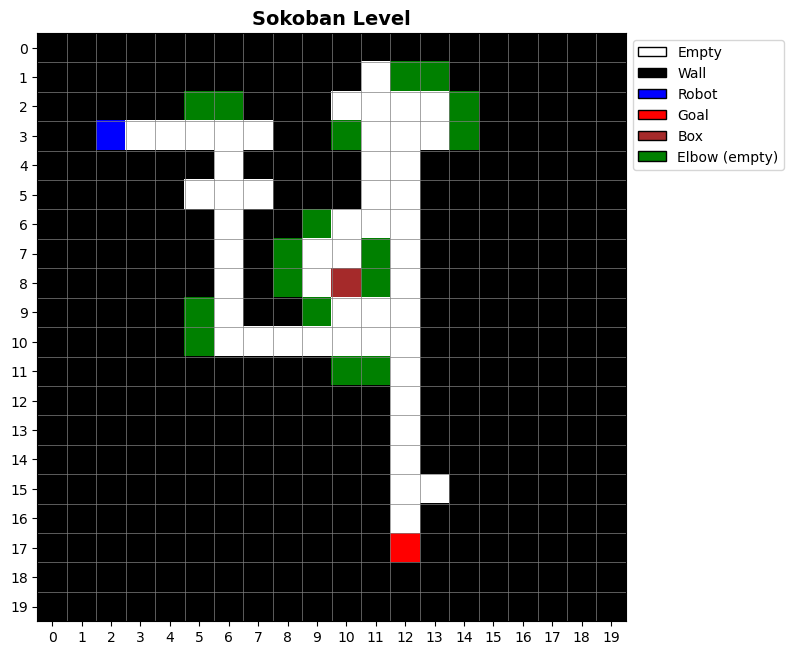

In [12]:
# Generate a level and the corresponding problem
sokoban_level = generate_maze(20, 20, erosion_strength=0.1)
stringified_level = maze_to_string(sokoban_level)
sokoban_problem = create_free_diagonal_sokoban_problem(stringified_level, with_axioms=False)

pretty_print(sokoban_level)
plot_level(sokoban_level)

# Solve the problem
with OneshotPlanner(problem_kind=sokoban_problem.kind) as planner:
    result = planner.solve(sokoban_problem) # , output_stream=sys.stdout
    if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
        print(f"{planner.name} found this plan:")
        print(result.plan)
    else:
        print("No plan found.")

## Optimized Sokoban

In [13]:
from collections import deque


def compute_reachable_from_position(level, start, block):
    """
    BFS to find all reachable cells from (start_x, start_y) with block at (block_x, block_y)
    """

    start_x, start_y = start
    block_x, block_y = block
    H, W = len(level), len(level[0])
    
    visited = set()
    queue = deque([(start_x, start_y)])
    visited.add((start_x, start_y))
    
    while queue:
        x, y = queue.popleft()
        
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            nx, ny = x + dx, y + dy
            
            if 0 <= nx < W and 0 <= ny < H and (nx, ny) not in visited:
                # Can't move through walls or the block position
                if level[ny][nx] != ENCODING['WALL'] and not (nx == block_x and ny == block_y):
                    visited.add((nx, ny))
                    queue.append((nx, ny))
    
    return visited

def create_optimized_sokoban_problem(level):
    problem = up.model.Problem("sokoban")
    
    loc = UserType("location")

    has_player = up.model.Fluent("has_player", BoolType(), l=loc)
    has_box = up.model.Fluent("has_box", BoolType(), l=loc)
    adjacent = up.model.Fluent("adjacent", BoolType(), l1=loc, l2=loc)
    adjacent_2 = up.model.Fluent("adjacent_2", BoolType(), l1=loc, l2=loc)

    problem.add_fluent(has_player, default_initial_value=False)
    problem.add_fluent(has_box, default_initial_value=False)
    problem.add_fluent(adjacent, default_initial_value=False)
    problem.add_fluent(adjacent_2, default_initial_value=False)

    # Precomputed can_reach fluent
    can_reach = up.model.Fluent("can-reach", BoolType(), l_from=loc, l_to=loc, l_block=loc)
    problem.add_fluent(can_reach, default_initial_value=False)

    cost_dict = {}

    # Push box
    push_box = up.model.InstantaneousAction("push-box", l=loc, x=loc, y=loc, z=loc)
    l, x, y, z = push_box.parameters
    push_box.add_precondition(adjacent(x, y))
    push_box.add_precondition(adjacent(y, z))
    push_box.add_precondition(adjacent_2(x, z))
    push_box.add_precondition(has_player(l))
    push_box.add_precondition(has_box(y))
    push_box.add_precondition(Not(has_box(z)))

    # Check precomputed reachability instead of axiom
    # Can agent at position l reach cell x with box in y?
    push_box.add_precondition(can_reach(l, x, y))

    push_box.add_effect(has_player(l), False)
    push_box.add_effect(has_player(y), True)
    push_box.add_effect(has_box(y), False)
    push_box.add_effect(has_box(z), True)

    cost_dict[push_box] = 1
    problem.add_action(push_box)

    problem.add_quality_metric(up.model.metrics.MinimizeActionCosts(cost_dict))

    # Encode level
    level_array = [[char for char in line] for line in level.splitlines()]
    num_col, num_row = len(level_array[0]), len(level_array)
    
    loc_objs = {}

    for x in range(num_col):
        for y in range(num_row):
            entry = level_array[y][x]
            if entry != ENCODING['WALL']:
                loc_id = f"loc-{x}-{y}"
                cur_obj = up.model.Object(loc_id, loc)
                loc_objs[loc_id] = cur_obj
                problem.add_object(cur_obj)

                if entry == ENCODING['ROBOT']:
                    problem.set_initial_value(has_player(cur_obj), True)
                elif entry == ENCODING['BLOCK']:
                    problem.set_initial_value(has_box(cur_obj), True)
                elif entry == ENCODING['GOAL']:
                    problem.add_goal(has_box(cur_obj))

    # Set adjacency relationships
    for obj1 in loc_objs:
        for obj2 in loc_objs:
            x1, y1 = map(int, str(obj1).split("-")[1:])
            x2, y2 = map(int, str(obj2).split("-")[1:])
            distance = abs(x1 - x2) + abs(y1 - y2)

            if distance == 1:
                problem.set_initial_value(adjacent(loc_objs[obj1], loc_objs[obj2]), True)
            elif distance == 2 and (x1 == x2 or y1 == y2):
                problem.set_initial_value(adjacent_2(loc_objs[obj1], loc_objs[obj2]), True)

    can_reach = problem.fluent("can-reach")    
    for obj1_id, obj1 in loc_objs.items():
        for obj_block_id, obj_block in loc_objs.items():
            # Parse coordinates
            x1, y1 = map(int, obj1_id.split("-")[1:])
            xb, yb = map(int, obj_block_id.split("-")[1:])
            
            # Compute reachable cells from (x1, y1) with block at (xb, yb)
            reachable = compute_reachable_from_position(level_array, (x1, y1), (xb, yb))
            
            # Set precomputed fluent values
            for target_x, target_y in reachable:
                target_id = f"loc-{target_x}-{target_y}"
                if target_id in loc_objs:
                    obj_target = loc_objs[target_id]
                    problem.set_initial_value(can_reach(obj1, obj_target, obj_block), True)

    return problem


##########
###ee#####
##r..#####
####.ee###
###e.b.###
###e...###
####ee..##
######@###
##########
##########



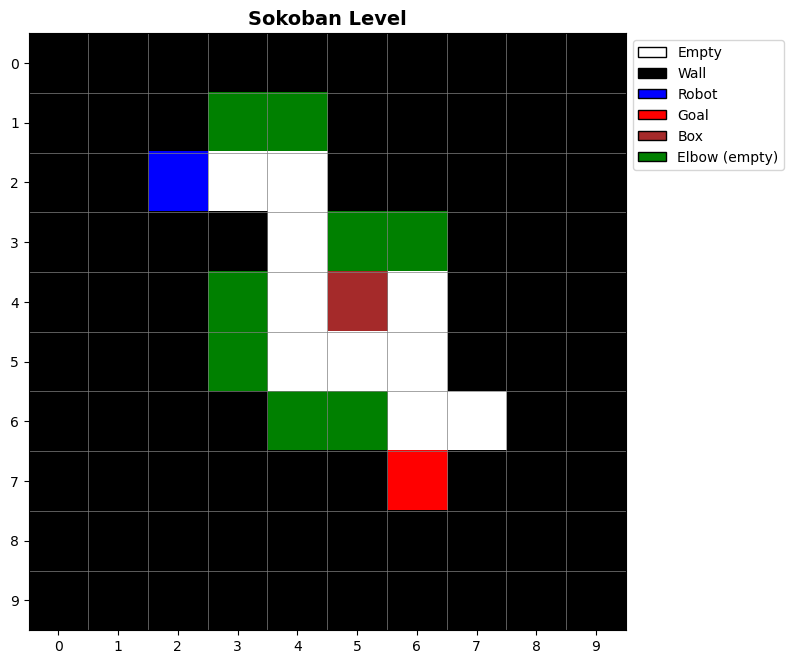

In [14]:
# Generate a level and the corresponding problem
sokoban_level = generate_maze(10, 10, erosion_strength=0.1)
stringified_level = maze_to_string(sokoban_level)

pretty_print(sokoban_level)
plot_level(sokoban_level)

sokoban_problem = create_optimized_sokoban_problem(stringified_level)


In [15]:
# Solve the problem
with OneshotPlanner(problem_kind=sokoban_problem.kind) as planner:
    result = planner.solve(sokoban_problem) # , output_stream=sys.stdout
    if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
        print(f"{planner.name} found this plan:")
        print(result.plan)
    else:
        print("No plan found.")

  *** Credits ***
  * In operation mode `OneshotPlanner` at line 2 of `/tmp/ipykernel_1632049/2616253311.py`, you are using the following planning engine:
  * Engine name: SymK
  * Developers:  David Speck (cf. https://github.com/speckdavid/symk/blob/master/README.md )
  * Description: SymK is a state-of-the-art domain-independent optimal and top-k planner.

SymK found this plan:
SequentialPlan:
    push-box(loc-2-2, loc-4-4, loc-5-4, loc-6-4)
    push-box(loc-5-4, loc-6-3, loc-6-4, loc-6-5)
    push-box(loc-6-4, loc-6-4, loc-6-5, loc-6-6)
    push-box(loc-6-5, loc-6-5, loc-6-6, loc-6-7)


## Relaxed sokoban

In [ ]:
def create_relaxed_sokoban_problem(level=sokoban_level):
    problem = up.model.Problem("sokoban")

    loc = UserType("location")

    has_player = up.model.Fluent("has_player", BoolType(), l=loc)
    has_box = up.model.Fluent("has_box", BoolType(), l=loc)
    adjacent = up.model.Fluent("adjacent", BoolType(), l1=loc, l2=loc)
    adjacent_2 = up.model.Fluent("adjacent_2", BoolType(), l1=loc, l2=loc)
    can_reach = up.model.Fluent("can_reach", BoolType(), l=loc)

    for fluent in [has_player, has_box, adjacent, adjacent_2, can_reach]:
        problem.add_fluent(fluent, default_initial_value=False)

    # Push box action with reachability precondition
    push_box = up.model.InstantaneousAction("push-box", l=loc, x=loc, y=loc, z=loc)
    l, x, y, z = push_box.parameters
    push_box.add_precondition(adjacent(x, y))
    push_box.add_precondition(adjacent(y, z))
    push_box.add_precondition(adjacent_2(x, z))
    push_box.add_precondition(has_player(l))
    push_box.add_precondition(can_reach(x))
    push_box.add_precondition(has_box(y))
    push_box.add_precondition(Not(has_box(z)))
    push_box.add_effect(has_player(l), False)
    push_box.add_effect(has_player(y), True)
    push_box.add_effect(has_box(y), False)
    push_box.add_effect(has_box(z), True)

    problem.add_action(push_box)
    problem.add_quality_metric(up.model.metrics.MinimizeActionCosts({push_box: 1}))

    # Encode level
    level_array = [[char for char in line] for line in level.splitlines()]
    num_col, num_row = len(level_array[0]), len(level_array)

    loc_objs = {}

    for x in range(num_col):
        for y in range(num_row):
            entry = level_array[y][x]
            if entry != ENCODING['WALL']:
                loc_id = f"loc-{x}-{y}"
                cur_obj = up.model.Object(loc_id, loc)
                loc_objs[loc_id] = cur_obj
                problem.add_object(cur_obj)

                if entry == ENCODING['ROBOT']:
                    problem.set_initial_value(has_player(cur_obj), True)
                elif entry == ENCODING['BLOCK']:
                    problem.set_initial_value(has_box(cur_obj), True)
                elif entry == ENCODING['GOAL']:
                    problem.add_goal(has_box(cur_obj))

                # Pre-mark all walkable cells as reachable
                problem.set_initial_value(can_reach(cur_obj), True)

    # Set adjacency relationships
    for obj1 in loc_objs:
        for obj2 in loc_objs:
            x1, y1 = map(int, str(obj1).split("-")[1:])
            x2, y2 = map(int, str(obj2).split("-")[1:])
            distance = abs(x1 - x2) + abs(y1 - y2)

            if distance == 1:
                problem.set_initial_value(adjacent(loc_objs[obj1], loc_objs[obj2]), True)
            elif distance == 2 and (x1 == x2 or y1 == y2):
                problem.set_initial_value(adjacent_2(loc_objs[obj1], loc_objs[obj2]), True)

    return problem

10 10
##########
#........#
#.......@#
#..#######
#..#######
#..#######
#..#######
#.b#######
#.r#######
##########



(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Sokoban Level'}>)

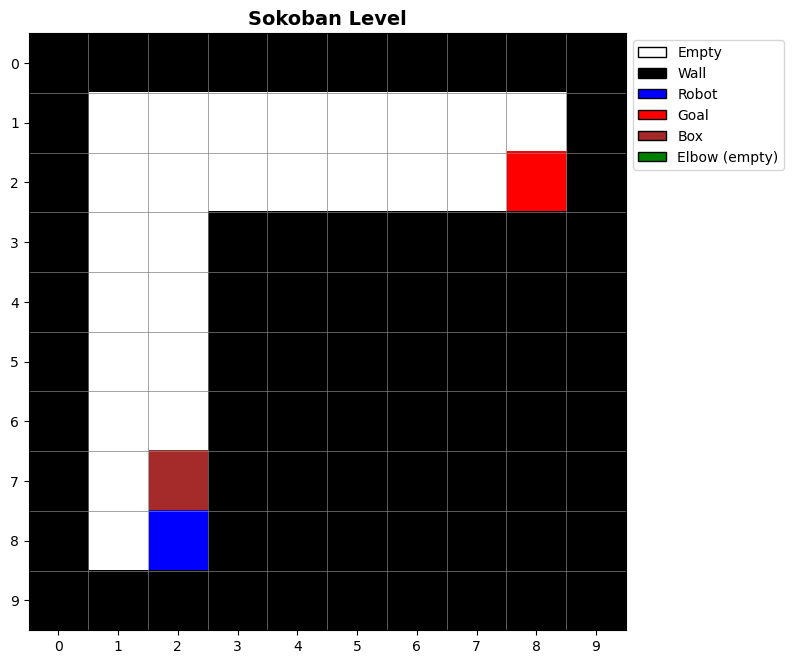

In [17]:
# Generate a level and the corresponding problem
stringified_level = """
##########
#........#
#.......@#
#..#######
#..#######
#..#######
#..#######
#.b#######
#.r#######
##########
""".strip()
sokoban_problem = create_relaxed_sokoban_problem(stringified_level)

sokoban_level = string_to_maze(stringified_level)
pretty_print(sokoban_level)
plot_level(sokoban_level)

In [18]:
# Solve the problem
with OneshotPlanner(problem_kind=sokoban_problem.kind) as planner:
    result = planner.solve(sokoban_problem) # , output_stream=sys.stdout
    if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
        print(f"{planner.name} found this plan:")
        print(result.plan)
    else:
        print("No plan found.")

  *** Credits ***
  * In operation mode `OneshotPlanner` at line 2 of `/tmp/ipykernel_1632049/2616253311.py`, you are using the following planning engine:
  * Engine name: SymK
  * Developers:  David Speck (cf. https://github.com/speckdavid/symk/blob/master/README.md )
  * Description: SymK is a state-of-the-art domain-independent optimal and top-k planner.

SymK found this plan:
SequentialPlan:
    push-box(loc-2-8, loc-2-8, loc-2-7, loc-2-6)
    push-box(loc-2-7, loc-2-7, loc-2-6, loc-2-5)
    push-box(loc-2-6, loc-2-6, loc-2-5, loc-2-4)
    push-box(loc-2-5, loc-2-5, loc-2-4, loc-2-3)
    push-box(loc-2-4, loc-2-4, loc-2-3, loc-2-2)
    push-box(loc-2-3, loc-1-2, loc-2-2, loc-3-2)
    push-box(loc-2-2, loc-2-2, loc-3-2, loc-4-2)
    push-box(loc-3-2, loc-3-2, loc-4-2, loc-5-2)
    push-box(loc-4-2, loc-4-2, loc-5-2, loc-6-2)
    push-box(loc-5-2, loc-5-2, loc-6-2, loc-7-2)
    push-box(loc-6-2, loc-6-2, loc-7-2, loc-8-2)


# Benchmarking

In [19]:
# We do not want to see the credits again and again, so let's disable them from now on.
up.shortcuts.get_environment().credits_stream = None

### 5x5 = 3x3 playable cells

#####
#..@#
#.b.#
#.r.#
#####

#####
#rb@#
#...#
#...#
#####

#####
#.b@#
#...#
#.r.#
#####

#####
#..@#
#..b#
#.r.#
#####

#####
#..@#
#.b.#
#r..#
#####

#####
#...#
#.b@#
#r..#
#####

#####
#r..#
#.b.#
#..@#
#####

#####
#...#
#...#
#rb@#
#####

#####
#..r#
#...#
#.b@#
#####

#####
#..r#
#...#
#@b.#
#####

4 3


(<Figure size 1500x1000 with 12 Axes>,
 array([<Axes: title={'center': 'Level 1'}>,
        <Axes: title={'center': 'Level 2'}>,
        <Axes: title={'center': 'Level 3'}>,
        <Axes: title={'center': 'Level 4'}>,
        <Axes: title={'center': 'Level 5'}>,
        <Axes: title={'center': 'Level 6'}>,
        <Axes: title={'center': 'Level 7'}>,
        <Axes: title={'center': 'Level 8'}>,
        <Axes: title={'center': 'Level 9'}>,
        <Axes: title={'center': 'Level 10'}>, <Axes: >, <Axes: >],
       dtype=object))

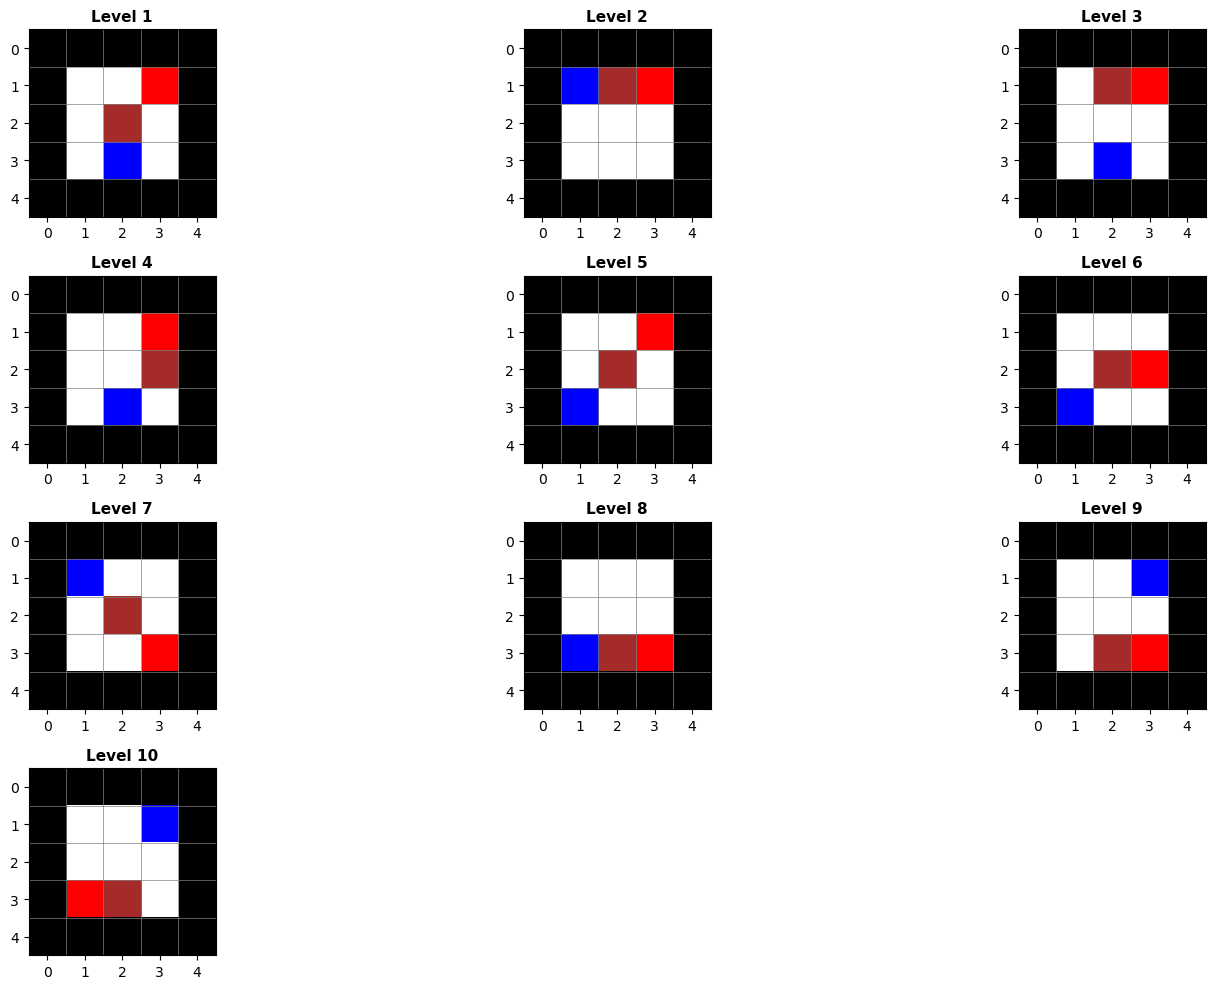

In [20]:
map_5x5_0 = """
#####
#..@#
#.b.#
#.r.#
#####
""".strip()

map_5x5_1 = """
#####
#rb@#
#...#
#...#
#####
""".strip()

map_5x5_2 = """
#####
#.b@#
#...#
#.r.#
#####
""".strip()

map_5x5_3 = """
#####
#..@#
#..b#
#.r.#
#####
""".strip()

map_5x5_4 = """
#####
#..@#
#.b.#
#r..#
#####
""".strip()

map_5x5_5 = """
#####
#...#
#.b@#
#r..#
#####
""".strip()

map_5x5_6 = """
#####
#r..#
#.b.#
#..@#
#####
""".strip()

map_5x5_7 = """
#####
#...#
#...#
#rb@#
#####
""".strip()

map_5x5_8 = """
#####
#..r#
#...#
#.b@#
#####
""".strip()

map_5x5_9 = """
#####
#..r#
#...#
#@b.#
#####
""".strip()

map_5x5_strings = [
    map_5x5_0,
    map_5x5_1,
    map_5x5_2,
    map_5x5_3,
    map_5x5_4,
    map_5x5_5,
    map_5x5_6,
    map_5x5_7,
    map_5x5_8,
    map_5x5_9,
]

map_5x5 = [string_to_maze(level) for level in map_5x5_strings]

for level in map_5x5:
    pretty_print(level)

plot_multiple_levels(map_5x5)

### 7x7 = 5x5 playable cells

#######
#..#..#
#..#b.#
#..#..#
#.@...#
#..r..#
#######

#######
#@....#
####..#
#..#..#
#..#b.#
#r....#
#######

#######
#..r#@#
#.###.#
#...#b#
###.#.#
#.....#
#######

#######
#.r##@#
#...#.#
#.#b#.#
#.....#
####..#
#######

#######
#.....#
#...b.#
#..####
#..r..#
#..@..#
#######

#######
#.....#
#.b##.#
#..##.#
#..##r#
#....@#
#######

#######
#....r#
#.##..#
#.....#
#.b##.#
#....@#
#######

#######
#.....#
#...#.#
#.b.#.#
#..##r#
#....@#
#######

#######
##@...#
##.r#.#
##..#.#
##..b.#
##..#.#
#######

#######
#.....#
#.b#..#
#..#r.#
#...###
#....@#
#######

4 3


(<Figure size 1500x1000 with 12 Axes>,
 array([<Axes: title={'center': 'Level 1'}>,
        <Axes: title={'center': 'Level 2'}>,
        <Axes: title={'center': 'Level 3'}>,
        <Axes: title={'center': 'Level 4'}>,
        <Axes: title={'center': 'Level 5'}>,
        <Axes: title={'center': 'Level 6'}>,
        <Axes: title={'center': 'Level 7'}>,
        <Axes: title={'center': 'Level 8'}>,
        <Axes: title={'center': 'Level 9'}>,
        <Axes: title={'center': 'Level 10'}>, <Axes: >, <Axes: >],
       dtype=object))

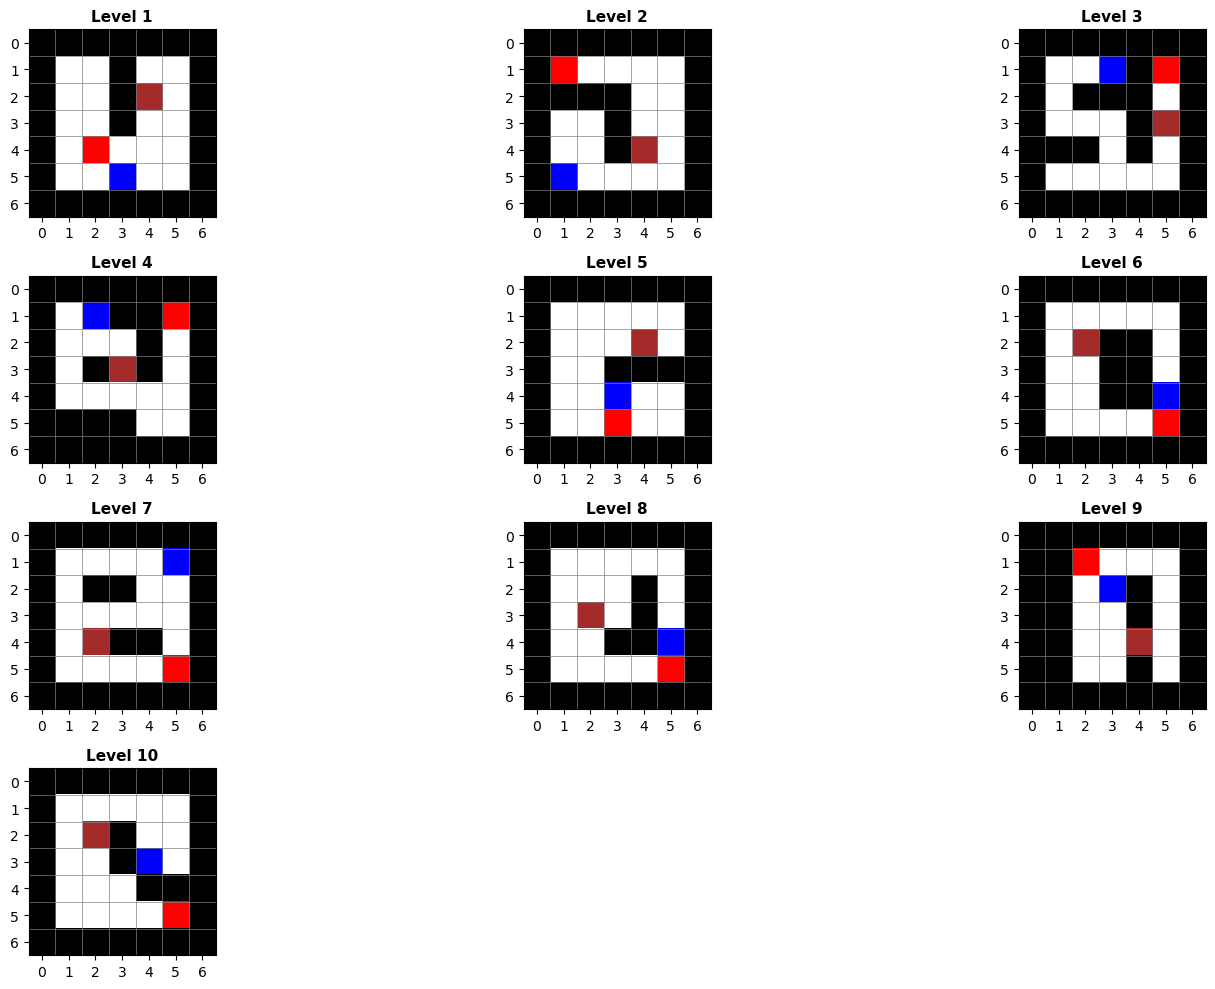

In [21]:
# 7x7 = 5x5 playable cells

map_7x7_0 = """
#######
#..#..#
#..#b.#
#..#..#
#.@...#
#..r..#
#######
""".strip()

map_7x7_1 = """
#######
#@....#
####..#
#..#..#
#..#b.#
#r....#
#######
""".strip()

map_7x7_2 = """
#######
#..r#@#
#.###.#
#...#b#
###.#.#
#.....#
#######
""".strip()

map_7x7_3 = """
#######
#.r##@#
#...#.#
#.#b#.#
#.....#
####..#
#######
""".strip()

map_7x7_4 = """
#######
#.....#
#...b.#
#..####
#..r..#
#..@..#
#######
""".strip()

map_7x7_5 = """
#######
#.....#
#.b##.#
#..##.#
#..##r#
#....@#
#######
""".strip()

map_7x7_6 = """
#######
#....r#
#.##..#
#.....#
#.b##.#
#....@#
#######
""".strip()

map_7x7_7 = """
#######
#.....#
#...#.#
#.b.#.#
#..##r#
#....@#
#######
""".strip()

map_7x7_8 = """
#######
##@...#
##.r#.#
##..#.#
##..b.#
##..#.#
#######
""".strip()

map_7x7_9 = """
#######
#.....#
#.b#..#
#..#r.#
#...###
#....@#
#######
""".strip()

map_7x7_strings = [
    map_7x7_0,
    map_7x7_1,
    map_7x7_2,
    map_7x7_3,
    map_7x7_4,
    map_7x7_5,
    map_7x7_6,
    map_7x7_7,
    map_7x7_8,
    map_7x7_9,
]

map_7x7 = [string_to_maze(level) for level in map_7x7_strings]

for level in map_7x7:
    pretty_print(level)

plot_multiple_levels(map_7x7)

### 9x9 = 7x7 playable cells

#########
#########
##r######
##.##ee##
#e.#e..##
#e...b@##
##....###
#########
#########

#########
#########
##r######
##.##ee##
#e.#e..##
#e...b@##
##....###
#########
#########

#########
#########
##r######
##.##ee##
##.#eb.##
#e.#e..##
#e....@##
####ee###
#########

#########
####ee###
#erb..###
#e....###
##....###
####..###
####.@###
#########
#########

#########
####ee###
##r...e##
##...b.##
#####..##
#####..##
#####.@##
#########
#########

#########
#########
#ere#####
#eb.#####
##....###
##..@..##
##.....##
####ee###
#########

#########
##ee#####
##r.e####
##..e####
##.######
#e.###@##
#eb....##
#####ee##
#########

#########
#########
##r##ee##
##.e...##
#e.e...##
#eb...@##
##...####
#########
#########

#########
####ee###
##r...e##
##.b..e##
##....###
###...###
####.@###
#########
#########

#########
##eeee###
##r...e##
##....be#
###....e#
###...e##
###.@####
#########
#########

4 3


(<Figure size 1500x1000 with 12 Axes>,
 array([<Axes: title={'center': 'Level 1'}>,
        <Axes: title={'center': 'Level 2'}>,
        <Axes: title={'center': 'Level 3'}>,
        <Axes: title={'center': 'Level 4'}>,
        <Axes: title={'center': 'Level 5'}>,
        <Axes: title={'center': 'Level 6'}>,
        <Axes: title={'center': 'Level 7'}>,
        <Axes: title={'center': 'Level 8'}>,
        <Axes: title={'center': 'Level 9'}>,
        <Axes: title={'center': 'Level 10'}>, <Axes: >, <Axes: >],
       dtype=object))

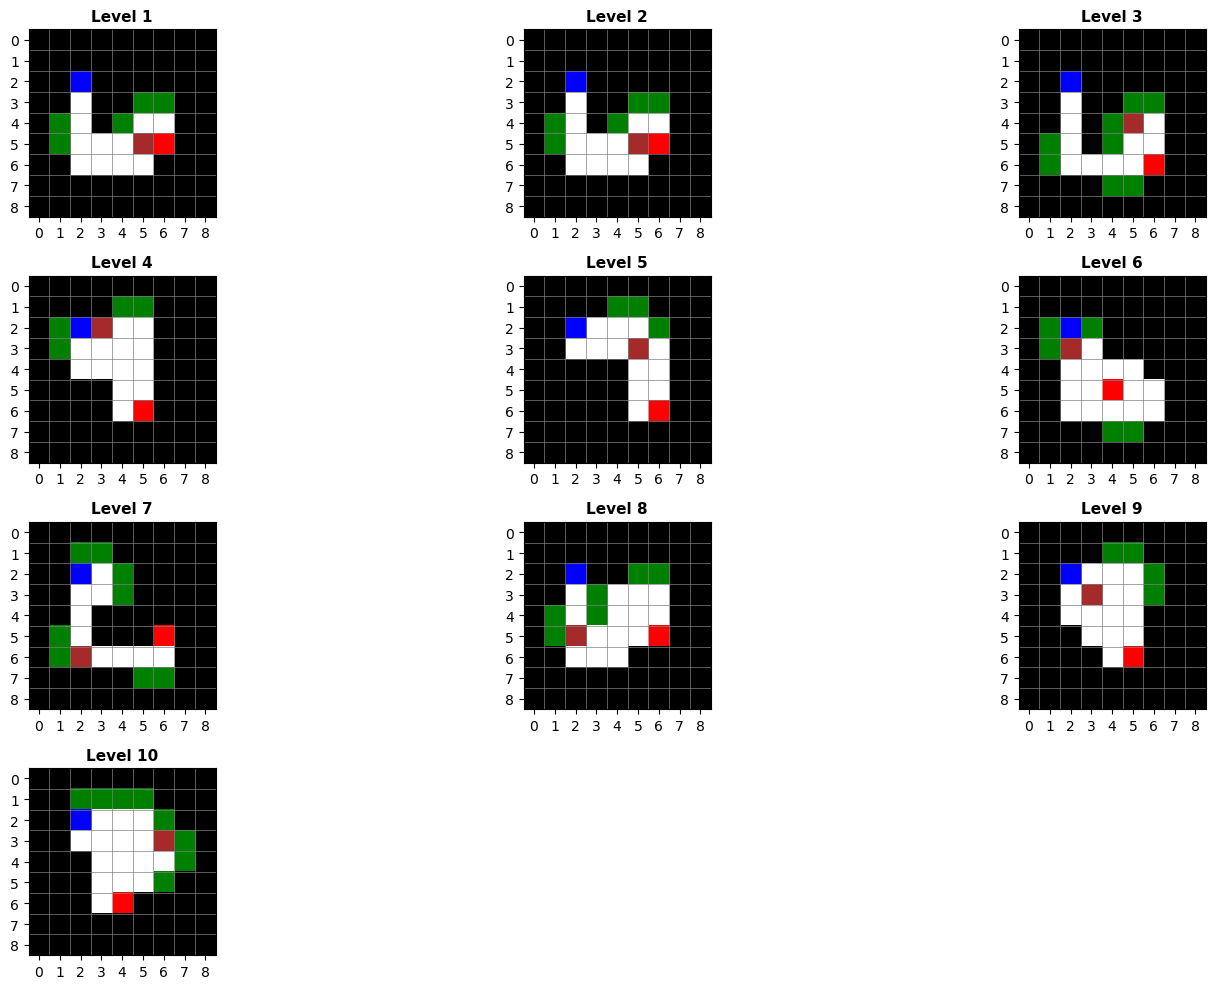

In [32]:
map_9x9 = [
    generate_maze(9, 9, corridor_width=2, num_road_iterations=1, seed=i)
    for i in range(10)
]

map_9x9_strings = [maze_to_string(level) for level in map_9x9]

for level in map_9x9:
    pretty_print(level)

plot_multiple_levels(map_9x9)

### 10x10 = 8x8 playable cells

##########
#........#
#.......@#
#..#######
#..#######
#..#######
#..#######
#.b#######
#.r#######
##########

##########
#####..@.#
#........#
#..#######
#..#######
#..#######
#..#######
#.b#######
#.r#######
##########

##########
#........#
#.......@#
#..####..#
#..####..#
#..####..#
#..####..#
#.b......#
#.r......#
##########

##########
#####.@###
#####..###
#......###
#......###
#..#######
#..#######
#.b#######
#.r#######
##########

##########
#@.......#
#........#
#######..#
#..####..#
#..####..#
#........#
#.b......#
#.r#######
##########

##########
#........#
#........#
#...##...#
#...##...#
#...##...#
#...##...#
#.b.##...#
#.r.##.@.#
##########

##########
#....@...#
#........#
#........#
####..####
####..####
####..####
#..b.....#
#.r......#
##########

##########
#.......@#
#..#######
#..#######
#........#
#........#
#######..#
#######b.#
#.r......#
##########

##########
#....@...#
#...##...#
#...##...#
#........#
#...##...#
#...##.b.#
#...##...#
#.r......#
##########

#

(<Figure size 1500x1000 with 12 Axes>,
 array([<Axes: title={'center': 'Level 1'}>,
        <Axes: title={'center': 'Level 2'}>,
        <Axes: title={'center': 'Level 3'}>,
        <Axes: title={'center': 'Level 4'}>,
        <Axes: title={'center': 'Level 5'}>,
        <Axes: title={'center': 'Level 6'}>,
        <Axes: title={'center': 'Level 7'}>,
        <Axes: title={'center': 'Level 8'}>,
        <Axes: title={'center': 'Level 9'}>,
        <Axes: title={'center': 'Level 10'}>, <Axes: >, <Axes: >],
       dtype=object))

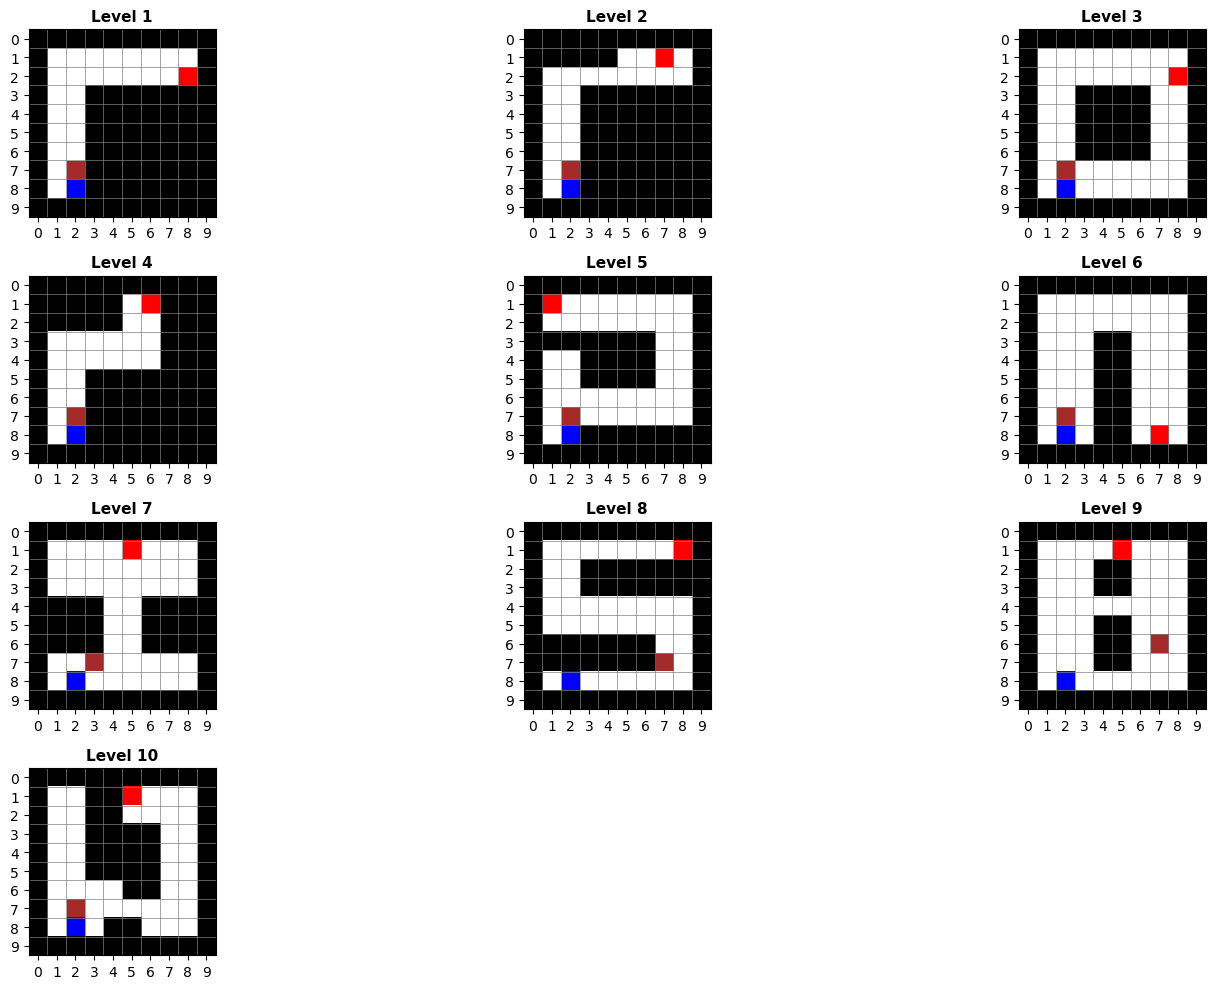

In [22]:
map_10x10_0 = """
##########
#........#
#.......@#
#..#######
#..#######
#..#######
#..#######
#.b#######
#.r#######
##########
""".strip()

map_10x10_1 = """
##########
#####..@.#
#........#
#..#######
#..#######
#..#######
#..#######
#.b#######
#.r#######
##########
""".strip()

map_10x10_2 = """
##########
#........#
#.......@#
#..####..#
#..####..#
#..####..#
#..####..#
#.b......#
#.r......#
##########
""".strip()

map_10x10_3 = """
##########
#####.@###
#####..###
#......###
#......###
#..#######
#..#######
#.b#######
#.r#######
##########
""".strip()

map_10x10_4 = """
##########
#@.......#
#........#
#######..#
#..####..#
#..####..#
#........#
#.b......#
#.r#######
##########
""".strip()

map_10x10_5 = """
##########
#........#
#........#
#...##...#
#...##...#
#...##...#
#...##...#
#.b.##...#
#.r.##.@.#
##########
""".strip()

map_10x10_6 = """
##########
#....@...#
#........#
#........#
####..####
####..####
####..####
#..b.....#
#.r......#
##########
""".strip()

map_10x10_7 = """
##########
#.......@#
#..#######
#..#######
#........#
#........#
#######..#
#######b.#
#.r......#
##########
""".strip()

map_10x10_8 = """
##########
#....@...#
#...##...#
#...##...#
#........#
#...##...#
#...##.b.#
#...##...#
#.r......#
##########
""".strip()

map_10x10_9 = """
##########
#..##@...#
#..##....#
#..####..#
#..####..#
#..####..#
#....##..#
#.b......#
#.r.##...#
##########
""".strip()

map_10x10_strings = [
    map_10x10_0,
    map_10x10_1,
    map_10x10_2,
    map_10x10_3,
    map_10x10_4,
    map_10x10_5,
    map_10x10_6,
    map_10x10_7,
    map_10x10_8,
    map_10x10_9,
]

map_10x10 = [string_to_maze(level) for level in map_10x10_strings]

for level in map_10x10:
    pretty_print(level)

plot_multiple_levels(map_10x10)

### 12x12 = 10x10 playable cells

############
############
##..########
##br###ee###
##.##e...###
#e.##e...e##
#e........e#
##........e#
#######.@###
############
############
############

############
##ee########
##.r########
##.#########
#e.ee#######
#e...e######
##..b.##@.##
####......##
#####....###
############
############
############

############
############
###ee#######
###rb#######
###..#######
###..e######
###...######
####..##ee##
####......##
#####....@##
############
############

############
######ee####
##r##e..####
##.##e..####
##.###..####
#e.#e...####
#e...b..####
##......####
######.@####
############
############
############

############
#######ee###
##r......e##
##.......e##
###.....e###
###..ee#####
###.b..#ee##
####......##
######...@##
############
############
############

############
###ee#######
###rb#######
###..#######
###..#######
###..#######
###..#@.####
###..#....##
###..#....e#
###.......e#
########ee##
############

############
##ee########
##...#######
##.r.#######
#e.e##

(<Figure size 1500x1000 with 12 Axes>,
 array([<Axes: title={'center': 'Level 1'}>,
        <Axes: title={'center': 'Level 2'}>,
        <Axes: title={'center': 'Level 3'}>,
        <Axes: title={'center': 'Level 4'}>,
        <Axes: title={'center': 'Level 5'}>,
        <Axes: title={'center': 'Level 6'}>,
        <Axes: title={'center': 'Level 7'}>,
        <Axes: title={'center': 'Level 8'}>,
        <Axes: title={'center': 'Level 9'}>,
        <Axes: title={'center': 'Level 10'}>, <Axes: >, <Axes: >],
       dtype=object))

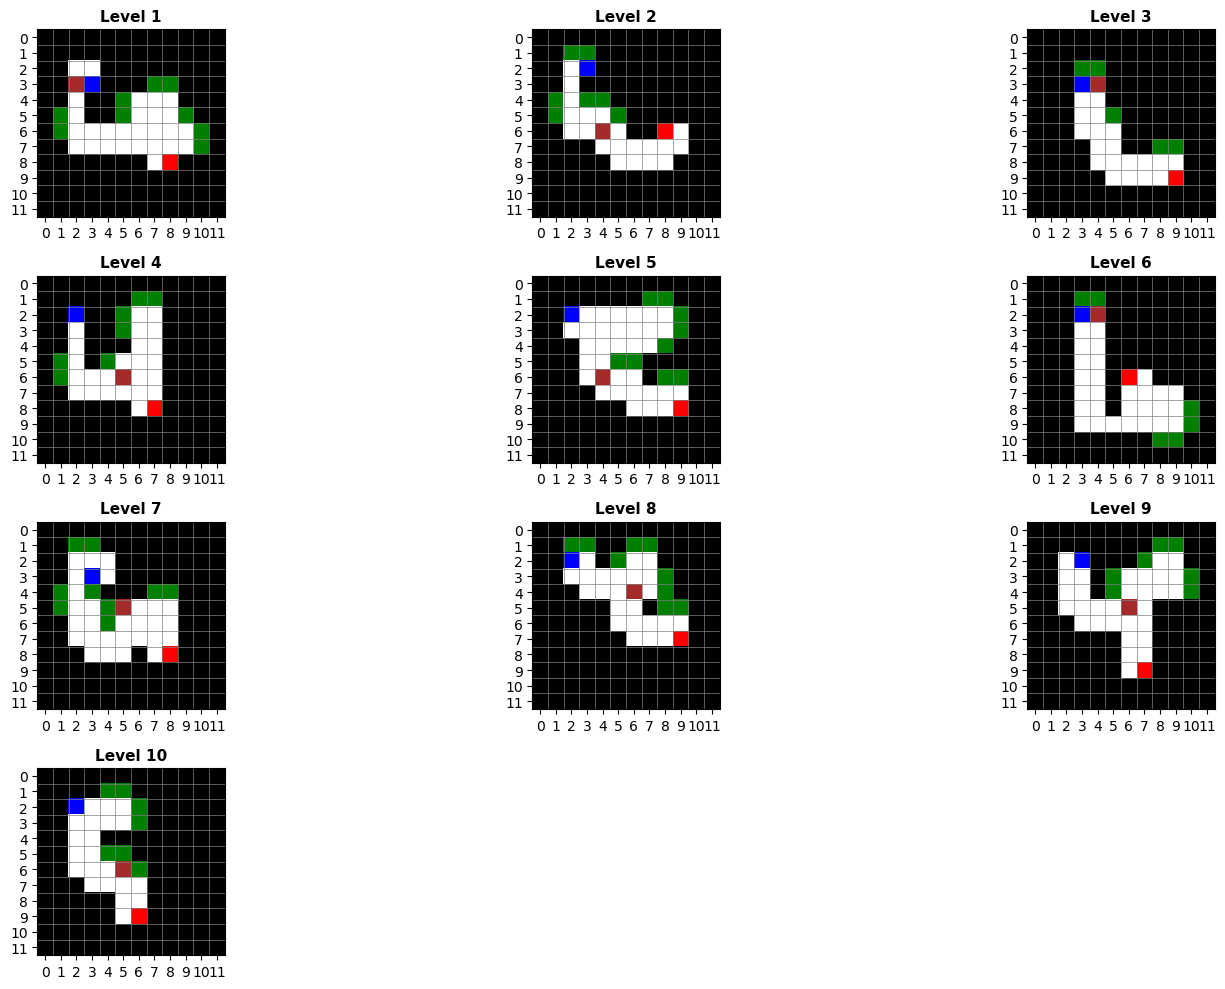

In [27]:
map_12x12 = [
    generate_maze(12, 12, corridor_width=2, num_road_iterations=1, seed=i)
    for i in range(10)
]

map_12x12_strings = [maze_to_string(level) for level in map_12x12]

for level in map_12x12:
    pretty_print(level)

plot_multiple_levels(map_12x12)

### Generated levels

2 3


(<Figure size 1500x1000 with 6 Axes>,
 array([<Axes: title={'center': 'Level 1'}>,
        <Axes: title={'center': 'Level 2'}>,
        <Axes: title={'center': 'Level 3'}>,
        <Axes: title={'center': 'Level 4'}>, <Axes: >, <Axes: >],
       dtype=object))

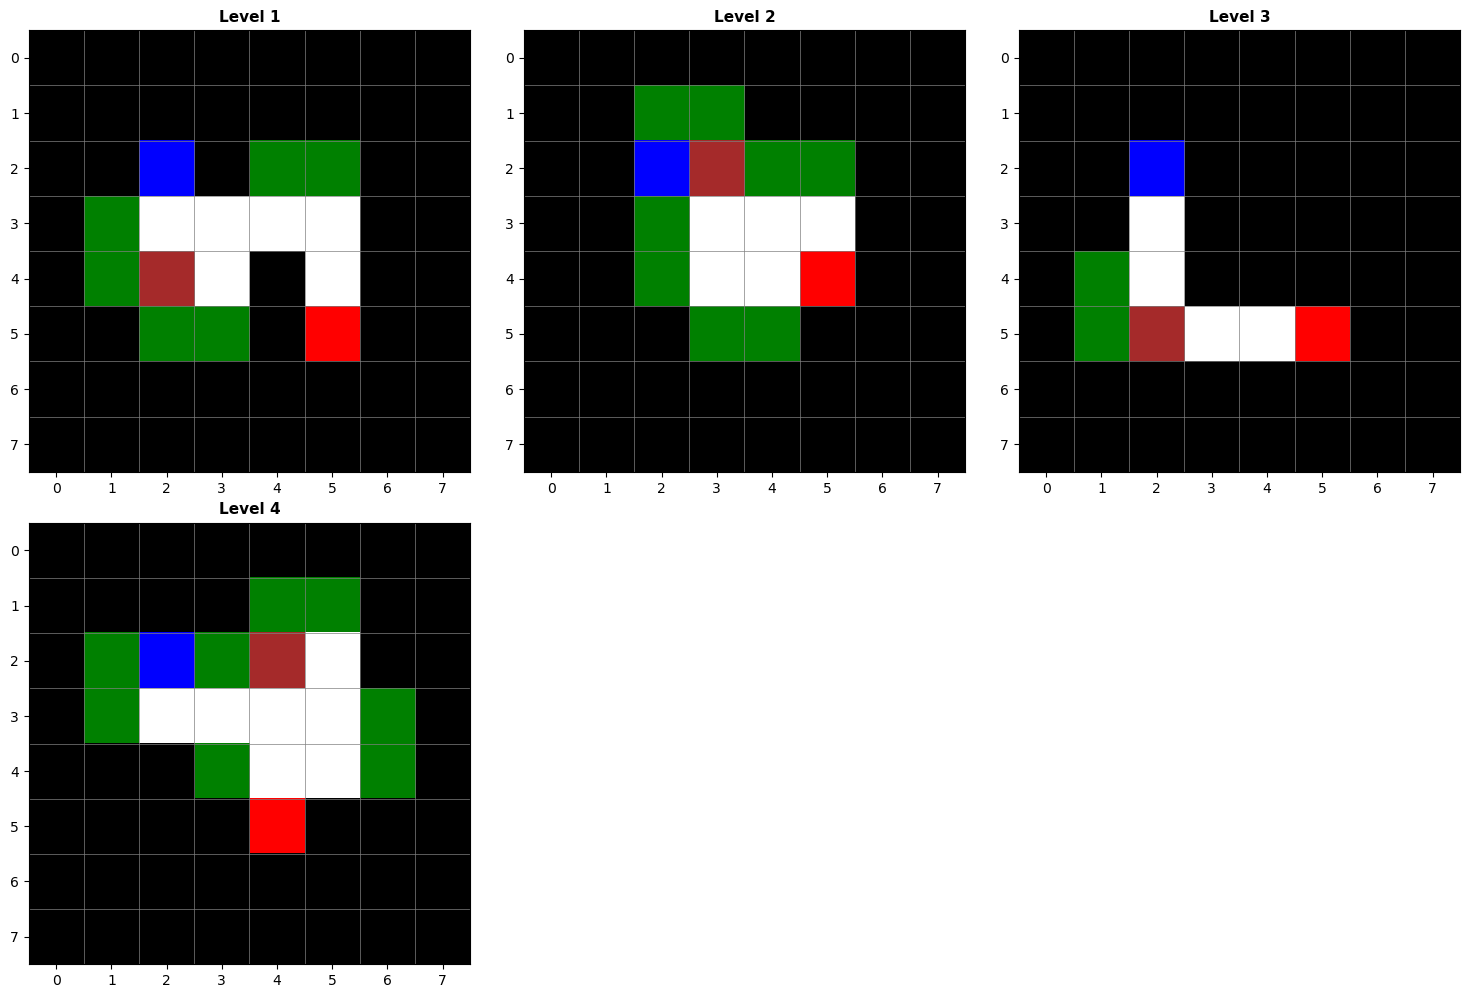

In [28]:
simulated_runs = 4
random_levels = []
for i in range(simulated_runs):
    random_levels.append(generate_maze(8, 8, seed=i))

plot_multiple_levels(random_levels)

### Benchmarking

In [37]:
import time
import statistics


MIN_BENCHMARKING_GRID_SIZE = 5
MAX_BENCHMARKING_GRID_SIZE = 8
DEFAULT_VARIANTS = [
    'original', 
    'original_axioms',
    'diagonal',
    'diagonal_axioms',
    'free_diagonal',
    'free_diagonal_axioms',
    'optimized'
]


def generate_problem(size, variant='original', seed=None, verbose=True):
    """
    Generate a level and the corresponding problem
    """

    level = generate_maze(*size, erosion=True, seed=seed)
    stringified_level = maze_to_string(level)

    variant = variant.lower()
    msg = None
    if variant == 'original':
        msg = 'Description: original problem formulation.'
        problem = create_sokoban_problem(stringified_level, with_axioms=False)
    elif variant == 'original_axioms':
        msg = 'Description: original problem formulation with axioms to encapsulate repeated moves.'
        problem = create_sokoban_problem(stringified_level, with_axioms=True)
    elif variant == 'diagonal':
        msg = 'Description: original problem formulation + diagonal movements.'
        problem = create_diagonal_sokoban_problem(stringified_level, with_axioms=False)
    elif variant == 'diagonal_axioms':
        msg = 'Description: original problem formulation + diagonal movements and axioms to encapsulate repeated moves.'
        problem = create_diagonal_sokoban_problem(stringified_level, with_axioms=True)
    elif variant == 'free_diagonal':
        msg = 'Description: original problem formulation + diagonal movements only when side blocks are not blocking the path.'
        problem = create_free_diagonal_sokoban_problem(stringified_level, with_axioms=False)
    elif variant == 'free_diagonal_axioms':
        msg = 'Description: original problem formulation + diagonal movements only when side blocks are not blocking the path and axiomx to encapsulate repeated moves.'
        problem = create_free_diagonal_sokoban_problem(stringified_level, with_axioms=True)
    elif variant == 'optimized':
        msg = 'Description: offline reachability analysis to avoid BFS (unexpectedly slower than original without axioms).'
        problem = create_optimized_sokoban_problem(stringified_level)
    elif variant == 'relaxed':
        msg = 'Description: original problem without BFS and reachablity always set to True for all cells.'
        problem = create_relaxed_sokoban_problem(stringified_level)
    else:
        raise ValueError(f"Unrecognized variant: {variant}")

    if verbose and msg:
        print(msg)

    return problem


def generate_problem_from_level(stringified_level, variant='original', verbose=True):
    """
    Generate a sokoban problem from to provided level
    """

    variant = variant.lower()
    msg = None
    if variant == 'original':
        msg = 'Description: original problem formulation.'
        problem = create_sokoban_problem(stringified_level, with_axioms=False)
    elif variant == 'original_axioms':
        msg = 'Description: original problem formulation with axioms to encapsulate repeated moves.'
        problem = create_sokoban_problem(stringified_level, with_axioms=True)
    elif variant == 'diagonal':
        msg = 'Description: original problem formulation + diagonal movements.'
        problem = create_diagonal_sokoban_problem(stringified_level, with_axioms=False)
    elif variant == 'diagonal_axioms':
        msg = 'Description: original problem formulation + diagonal movements and axioms to encapsulate repeated moves.'
        problem = create_diagonal_sokoban_problem(stringified_level, with_axioms=True)
    elif variant == 'free_diagonal':
        msg = 'Description: original problem formulation + diagonal movements only when side blocks are not blocking the path.'
        problem = create_free_diagonal_sokoban_problem(stringified_level, with_axioms=False)
    elif variant == 'free_diagonal_axioms':
        msg = 'Description: original problem formulation + diagonal movements only when side blocks are not blocking the path and axiomx to encapsulate repeated moves.'
        problem = create_free_diagonal_sokoban_problem(stringified_level, with_axioms=True)
    elif variant == 'optimized':
        msg = 'Description: offline reachability analysis to avoid BFS (unexpectedly slower than original without axioms).'
        problem = create_optimized_sokoban_problem(stringified_level)
    elif variant == 'relaxed':
        msg = 'Description: original problem without BFS and reachablity always set to True for all cells.'
        problem = create_relaxed_sokoban_problem(stringified_level)
    else:
        raise ValueError(f"Unrecognized variant: {variant}")

    if verbose and msg:
        print(msg)

    return problem


def solve(problem):
    """
    Solve the problem
    """
    # Solve the problem
    with OneshotPlanner(problem_kind=problem.kind) as planner:
        result = planner.solve(problem) # , output_stream=sys.stdout
        if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
            # print(f"{planner.name} found this plan:")
            # print(result.plan)
            return True
        else:
            # print("No plan found.")
            return False


def benchmark(
        min_size=MIN_BENCHMARKING_GRID_SIZE, 
        max_size=MAX_BENCHMARKING_GRID_SIZE, 
        variants=DEFAULT_VARIANTS,
        runs=20,
        verbose=True
    ):

    results = {}
    for variant in variants:

        if verbose:
            print(f'Variant: {variant}')

        variant_results = []
        for size in range(min_size, max_size + 1):

            actual_size = (size + 2, size + 2)


            times = []
            for i in range(runs):

                problem = generate_problem(actual_size, variant=variant, seed=i, verbose=verbose)

                start = time.perf_counter()
                solve(problem)
                end = time.perf_counter()

                times.append(end - start)

            avg_time = statistics.mean(times)
            std_dev = statistics.stdev(times) if len(times) > 1 else 0.0

            variant_results.append((size, avg_time, std_dev))

            if verbose:
                print(f"\t{size}x{size} -> avg: {avg_time:.6f}s, std: {std_dev:.6f}s")

        results[variant] = variant_results
        print()

    return results


COMPREHENSIVE_BENCHMARK = False
if COMPREHENSIVE_BENCHMARK:
    results = benchmark(
        runs=50, 
        min_size=4,
        max_size=8,
        variants=[
            'original', 
            'original_axioms', 
            'optimized',
        ]
    )

    print("\nResults:")
    for variant, res in results.items():
        print(f"\tVariant: {variant}")
        for size, avg, std in res:
            print(f"\t\t{size}x{size}\t{avg:.6f}\t{std:.6f}")

In [38]:
def benchmark_levels(levels, variant='original', runs=20, verbose=True):

    run_times = []

    for _ in range(runs):
        total = 0.0

        for level in levels:
            problem = generate_problem_from_level(level, variant=variant, verbose=verbose)

            start = time.perf_counter()
            solve(problem)
            end = time.perf_counter()

            total += (end - start)

        run_avg = total / len(levels)
        run_times.append(run_avg)

    avg_time = statistics.mean(run_times)
    std_dev = statistics.stdev(run_times) if len(run_times) > 1 else 0.0

    return avg_time, std_dev


def benchmark_variant(levels, variant='original', runs=20, verbose=True):

    if verbose:
        print(f"Variant: {variant}")

    results = {}
    for level_collection in levels:
        avg_time, std_dev = benchmark_levels(level_collection, variant=variant, runs=runs, verbose=verbose)
        sample_level = level_collection[0]
        sample_level = string_to_maze(sample_level)
        H, W = len(sample_level), len(sample_level[0])
        results[(H, W)] = (avg_time, std_dev)

        if verbose:
            print(f"\t{H}x{W} -> avg: {avg_time:.6f}s, std: {std_dev:.6f}s")

    return results


BENCHMARK_VARIANT = True
if BENCHMARK_VARIANT:
    variant = 'relaxed'
    results = benchmark_variant(
        levels = [
            map_7x7_strings,
            map_9x9_strings,
            map_12x12_strings,
        ],
        runs=20, 
        variant=variant
    )

    print(f"Variant: {variant}")
    for size, res in results.items():
        H, W = size
        avg, std = res
        print(f"\t{H}x{W}\t{avg:.6f}\t{std:.6f}")

Variant: relaxed
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: original problem without BFS and reachablity always set to True for all cells.
7 7
Description: origin

# Timeseries

In [ ]:
import re
from typing import List, Tuple
import copy

ENCODING = {
    'WALL': '#',
    'EMPTY': '.',
    'ROBOT': 'r',
    'GOAL': '@',
    'BLOCK': 'b',
    'ELBOW': 'e'
}


def parse_plan_action(action_string: str) -> Tuple[str, List[str]]:
    """
    Extract action name and parameters
    Example: "push-box(loc-4-5, loc-13-7, loc-13-6, loc-13-5)"
    """
    match = re.match(r'([\w-]+)\((.*)\)', action_string.strip())
    if not match:
        return None, None
    
    action_name = match.group(1)
    params_str = match.group(2)
    params = [p.strip() for p in params_str.split(',')]
    
    return action_name, params


def location_to_coords(loc_id) -> Tuple[int, int]:
    """
    Convert "loc-x-y" to (x, y)
    """
    parts = str(loc_id).split('-')
    x, y = int(parts[1]), int(parts[2])
    return x, y


def simulate_plan(initial_board: List[List[str]], plan_actions: List) -> List[List[List[str]]]:
    # Track goal positions separately so they persist when blocks move
    height, width = len(initial_board), len(initial_board[0])
    goal_positions = set()
    
    for y in range(height):
        for x in range(width):
            if initial_board[y][x] == ENCODING['GOAL']:
                goal_positions.add((x, y))
    
    # Initialize with the starting board state
    board_states = []
    current_board = [row[:] for row in initial_board]  # Deep copy
    board_states.append([row[:] for row in current_board])
    
    # Process each action
    for action in plan_actions:

        # action_name = action.action.name
        # params = action.action.parameters
        action_name, params = parse_plan_action(str(action))
        print(f"Action name: {action_name}")
        print(f"Action params: {params}")
        print()

        if action_name == "push-box":
            # Handle both 3-param (no axioms) and 4-param (with axioms) versions
            if len(params) == 3:
                # Without axioms: push-box(x, y, z)
                # x = robot position, y = box position, z = new box position
                x, y, z = params
                x_coords = location_to_coords(x)
                y_coords = location_to_coords(y)
                z_coords = location_to_coords(z)
                
                # Clear old player position (restore goal if it was there)
                if x_coords in goal_positions:
                    current_board[x_coords[1]][x_coords[0]] = ENCODING['GOAL']
                else:
                    current_board[x_coords[1]][x_coords[0]] = ENCODING['EMPTY']
                
                # Clear old box position (restore goal if it was there)
                if y_coords in goal_positions:
                    current_board[y_coords[1]][y_coords[0]] = ENCODING['GOAL']
                else:
                    current_board[y_coords[1]][y_coords[0]] = ENCODING['EMPTY']
                
                # Move player to y position
                current_board[y_coords[1]][y_coords[0]] = ENCODING['ROBOT']
                
                # Move box to z position
                current_board[z_coords[1]][z_coords[0]] = ENCODING['BLOCK']
                
            elif len(params) == 4:
                # With axioms: push-box(l, x, y, z)
                # l = reachable position, x = position adjacent to box, y = box position, z = new box position
                l, x, y, z = params
                x_coords = location_to_coords(x)
                y_coords = location_to_coords(y)
                z_coords = location_to_coords(z)
                
                # Clear old player position (restore goal if it was there)
                # Note: player could be anywhere reachable, we find it on the board
                # For now, assume player is at x (adjacent to box)
                if x_coords in goal_positions:
                    current_board[x_coords[1]][x_coords[0]] = ENCODING['GOAL']
                else:
                    current_board[x_coords[1]][x_coords[0]] = ENCODING['EMPTY']
                
                # Clear old box position (restore goal if it was there)
                if y_coords in goal_positions:
                    current_board[y_coords[1]][y_coords[0]] = ENCODING['GOAL']
                else:
                    current_board[y_coords[1]][y_coords[0]] = ENCODING['EMPTY']
                
                # Move player to y position
                current_board[y_coords[1]][y_coords[0]] = ENCODING['ROBOT']
                
                # Move box to z position
                current_board[z_coords[1]][z_coords[0]] = ENCODING['BLOCK']
        
        elif action_name == "move":
            # Parameters: fr (from location), to (to location)
            if len(params) == 2:
                fr, to = params
                fr_coords = location_to_coords(fr)
                to_coords = location_to_coords(to)
                
                # Clear old position (restore goal if it was there)
                if fr_coords in goal_positions:
                    current_board[fr_coords[1]][fr_coords[0]] = ENCODING['GOAL']
                else:
                    current_board[fr_coords[1]][fr_coords[0]] = ENCODING['EMPTY']
                
                # Move player to new position
                current_board[to_coords[1]][to_coords[0]] = ENCODING['ROBOT']

        elif action_name == "move-diag":
            # Parameters: fr (from location), to (to location)
            if len(params) == 2:
                fr, to = params
                fr_coords = location_to_coords(fr)
                to_coords = location_to_coords(to)
                
                # Clear old position (restore goal if it was there)
                if fr_coords in goal_positions:
                    current_board[fr_coords[1]][fr_coords[0]] = ENCODING['GOAL']
                else:
                    current_board[fr_coords[1]][fr_coords[0]] = ENCODING['EMPTY']
                
                # Move player to new position
                current_board[to_coords[1]][to_coords[0]] = ENCODING['ROBOT']
        
        # Add current board state to history
        board_states.append([row[:] for row in current_board])
    
    return board_states


def print_board_states(board_states: List[List[List[str]]], max_states: int = None):
    # Print all board states, optionally limiting the number shown
    states_to_print = board_states if max_states is None else board_states[:max_states]
    
    for i, board in enumerate(states_to_print):
        print(f"\n--- Step {i} ---")
        for row in board:
            print(''.join(row))


def board_to_string(board: List[List[str]]) -> str:
    return '\n'.join(''.join(row) for row in board)


def get_board_configs_as_list(board_states: List[List[List[str]]]) -> List[str]:
    # Convert all board states to string format
    return [board_to_string(board) for board in board_states]


In [ ]:
sample_level = [
    ['#', '#', '#', '#', '#'],
    ['#', 'r', '.', '.', '#'],
    ['#', '.', 'b', '.', '#'],
    ['#', '.', '.', '@', '#'],
    ['#', '#', '#', '#', '#'],
]

plot_level(sample_level)

In [ ]:
# Formulate the problem
problem = create_sokoban_problem(maze_to_string(sample_level), with_axioms=False)

# Solve it once again
with OneshotPlanner(problem_kind=problem.kind) as planner:
    result = planner.solve(problem) # , output_stream=sys.stdout
    if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
        print(f"{planner.name} found this plan:")
        # print(result.plan)
    else:
        print("No plan found.")

# Extract the plan
actions = result.plan.actions
for action in actions:
    print(action)

In [ ]:
board_states = simulate_plan(sample_level, actions)
print_board_states(board_states)

In [ ]:
# Formulate the problem
sample_level = generate_maze(10, 10)
problem = create_free_diagonal_sokoban_problem(maze_to_string(sample_level), with_axioms=False)
plot_level(sample_level)

# Solve it once again
with OneshotPlanner(problem_kind=problem.kind) as planner:
    result = planner.solve(problem) # , output_stream=sys.stdout
    if result.status in unified_planning.engines.results.POSITIVE_OUTCOMES:
        print(f"{planner.name} found this plan:")
        # print(result.plan)
    else:
        print("No plan found.")

# Extract the plan
actions = result.plan.actions
for action in actions:
    print(action)

board_states = simulate_plan(sample_level, actions)
print_board_states(board_states)

# Action remapping

In [ ]:
def parse_plan_action(action_string: str) -> Tuple[str, List[str]]:
    # Extract action name and parameters
    # Example: "push-box(loc-4-5, loc-13-7, loc-13-6, loc-13-5)"
    match = re.match(r'([\w-]+)\((.*)\)', action_string.strip())
    if not match:
        return None, None
    
    action_name = match.group(1)
    params_str = match.group(2)
    params = [p.strip() for p in params_str.split(',')]
    
    return action_name, params


def location_to_coords(loc_id) -> Tuple[int, int]:
    # Convert "loc-x-y" to (x, y)
    parts = str(loc_id).split('-')
    x, y = int(parts[1]), int(parts[2])
    return x, y


def plan_to_simple_steps(plan_actions: List) -> List[str]:
    """
    Converts a list of plan actions into a sequence of simple directional steps.

    - Move actions
        before: "move l1 l2"
        after: "move_up" / "move_down" / "move_left" / "move_right"
    - Push-box actions
        before: "push-box l1 l2"
        after: "push_up" / "push_down" / "push_left" / "push_right"

    Supports both 3-param push-box(robot, box, new_box)
    and 4-param push-box(reachable, robot, box, new_box).
    """

    direction_map = {
        (0, -1): ("move_up", "push_up"),
        (0, 1): ("move_down", "push_down"),
        (-1, 0): ("move_left", "push_left"),
        (1, 0): ("move_right", "push_right"),
        (1, 1): ("move_right_down", "push_right_down"),
        (-1, 1): ("move_left_down", "push_left_down"),
        (1, -1): ("move_right_up", "push_right_up"),
        (-1, -1): ("move_left_up", "push_left_up")
    }

    steps = []

    for action in plan_actions:
        action_name, params = parse_plan_action(str(action))

        if action_name == "move":
            if len(params) != 2:
                raise ValueError(f"Expected 2 params for move, got {len(params)}: {params}")
            fr_coords = location_to_coords(params[0])
            to_coords = location_to_coords(params[1])
            delta = (to_coords[0] - fr_coords[0], to_coords[1] - fr_coords[1])
            if delta not in direction_map:
                raise ValueError(f"Non-cardinal move delta {delta} in action: {action}")
            steps.append(direction_map[delta][0])  # plain movement

        elif action_name == "move-diag":
            if len(params) != 2:
                raise ValueError(f"Expected 2 params for move, got {len(params)}: {params}")
            fr_coords = location_to_coords(params[0])
            to_coords = location_to_coords(params[1])
            delta = (to_coords[0] - fr_coords[0], to_coords[1] - fr_coords[1])
            if delta not in direction_map:
                raise ValueError(f"Non-cardinal move delta {delta} in action: {action}")
            steps.append(direction_map[delta][0])  # plain movement

        elif action_name == "push-box":
            if len(params) == 3:
                # push-box(robot, box, new_box)
                box_coords = location_to_coords(params[1])
                new_box_coords = location_to_coords(params[2])
            elif len(params) == 4:
                # push-box(reachable, robot, box, new_box)
                box_coords = location_to_coords(params[2])
                new_box_coords = location_to_coords(params[3])
            else:
                raise ValueError(f"Expected 3 or 4 params for push-box, got {len(params)}: {params}")

            delta = (new_box_coords[0] - box_coords[0], new_box_coords[1] - box_coords[1])
            if delta not in direction_map:
                raise ValueError(f"Non-cardinal push delta {delta} in action: {action}")
            steps.append(direction_map[delta][1])  # push movement

        else:
            raise ValueError(f"Unknown action: {action_name}")

    return steps

actions_mapped = plan_to_simple_steps(actions)
for action in actions_mapped:
    print(action)